In [91]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx

#select particular representative gauge
reg = 'CT'
columnname = str(38)
mask_size = '1658'
list_size = ['892','1658','3454','7071']  
train_size = list_size[1]

#read combined dataframe
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

eve_def = eve_perf['max_absdz']>= 0.1
eve_nodef = eve_perf['max_absdz']< 0.1
rate = eve_perf['mean_prob'].values
Control_IDAG = pd.read_csv(f'{MLDir}/risk/plots/Control_POI.csv')
exposure = pd.read_csv(f'{MLDir}/risk/loss/building_exposure.csv',header=0)


PML and AAL - asset level

In [3]:
PMLtrue = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_true.csv')
PML0 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_{list_size[0]}.csv')
PML1 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_{list_size[1]}.csv')
PML2 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_{list_size[2]}.csv')
PML3 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_{list_size[3]}.csv')

AALtrue = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_asset_true.csv')
AAL0 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_asset_{list_size[0]}.csv')
AAL1 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_asset_{list_size[1]}.csv')
AAL2 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_asset_{list_size[2]}.csv')
AAL3 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_asset_{list_size[3]}.csv')

# RP = [10, 20, 50,
#     100, 200, 500, 
#     1000, 2000, 5000,
#     10000, 20000, 50000, 
#     100000, 200000, 500000, 
#     1000000, 2000000, 5000000, 
#     10000000, 20000000, 50000000, 
#     100000000]
RP = np.logspace(3,8,50,base=10)
PoE = [1/rp for rp in RP]   
t = [1e-4,1e-6,1e-8]
# get dtype of the IDAG
IDAG = Control_IDAG['IDAG'].values
# IDAG = np.append(IDAG,'19087015000002073100')
# PMLtrue = PMLtrue[PMLtrue['IDAG'].isin(IDAG)]



/tmp/ipykernel_52340/308661198.py:15: RuntimeWarning: invalid value encountered in divide
  rel_error_0 = (pml_true - pml_0) / pml_true
/tmp/ipykernel_52340/308661198.py:16: RuntimeWarning: invalid value encountered in divide
  rel_error_1 = (pml_true - pml_1) / pml_true
/tmp/ipykernel_52340/308661198.py:17: RuntimeWarning: invalid value encountered in divide
  rel_error_2 = (pml_true - pml_2) / pml_true
/tmp/ipykernel_52340/308661198.py:18: RuntimeWarning: invalid value encountered in divide
  rel_error_3 = (pml_true - pml_3) / pml_true


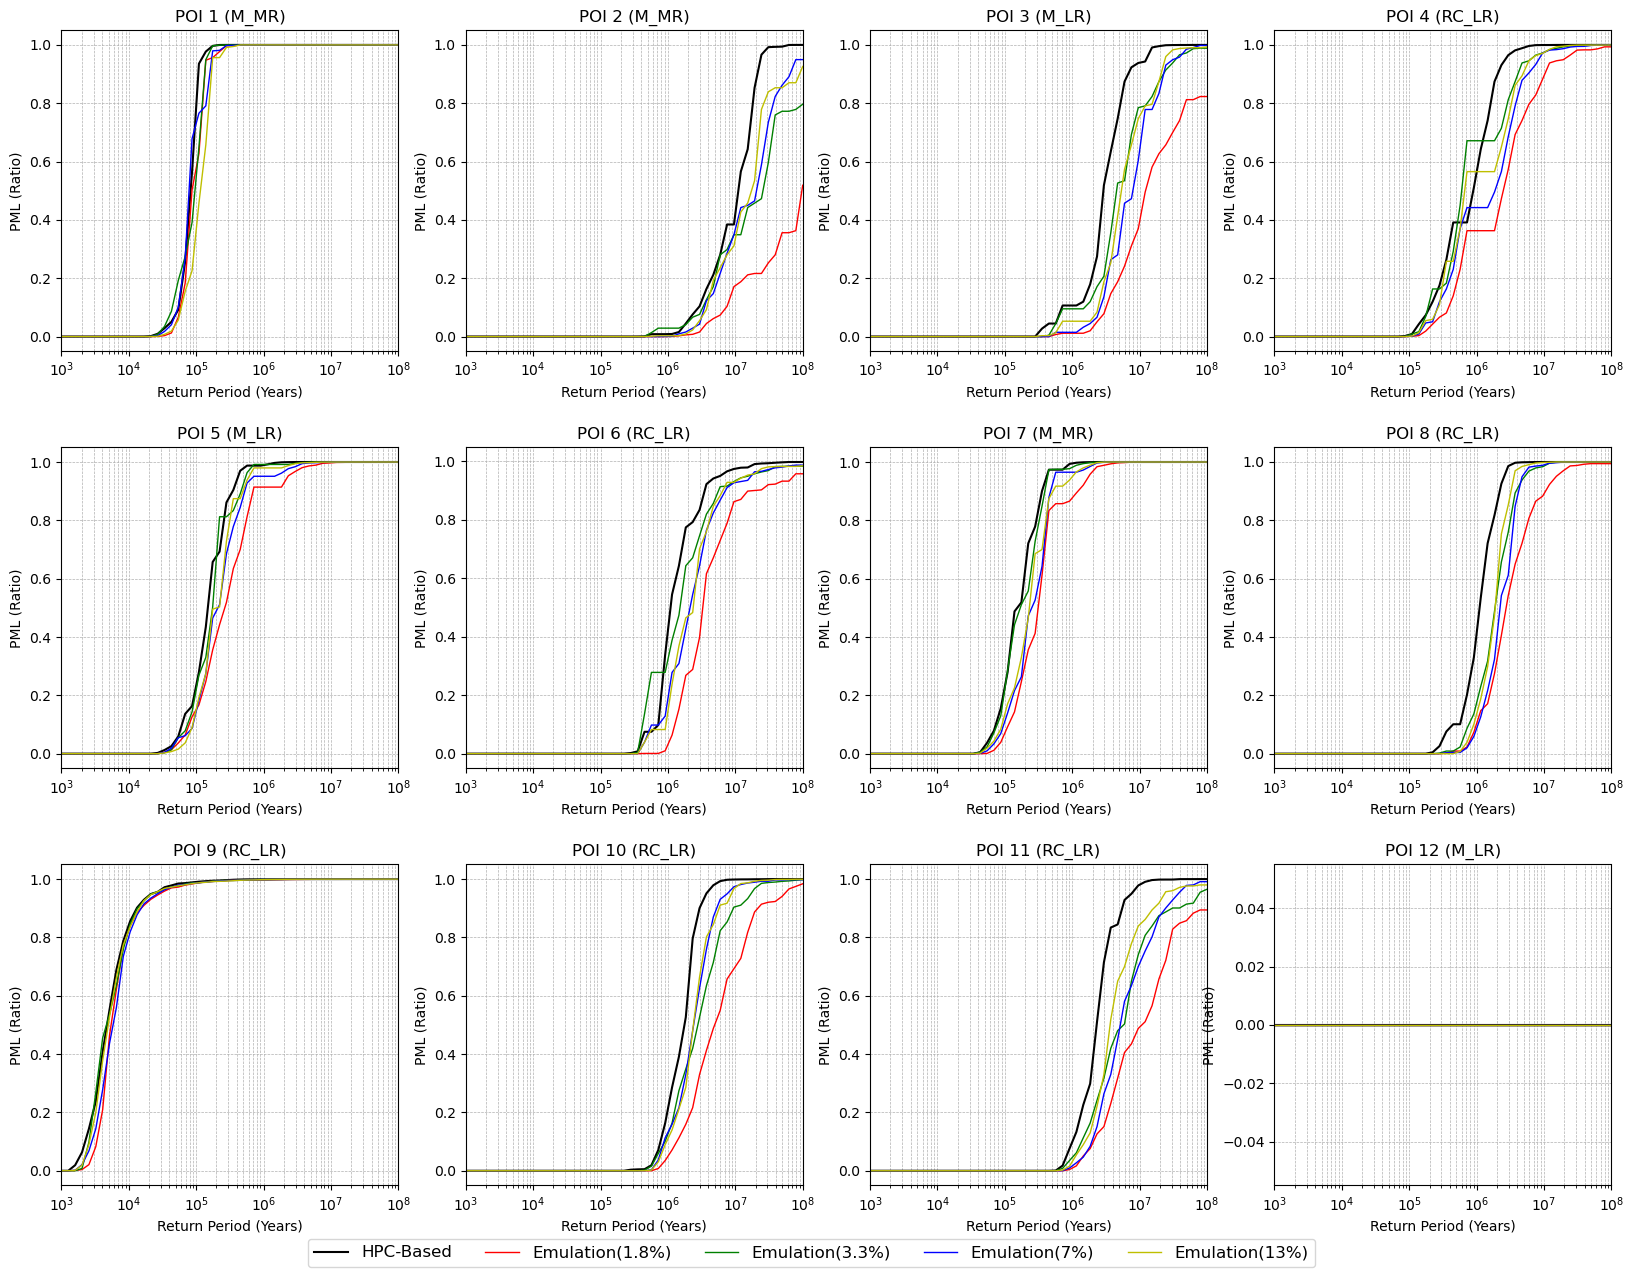

/tmp/ipykernel_52340/308661198.py:70: RuntimeWarning: invalid value encountered in divide
  rel_error_0 = (pml_true - pml_0) / pml_true
/tmp/ipykernel_52340/308661198.py:71: RuntimeWarning: invalid value encountered in divide
  rel_error_1 = (pml_true - pml_1) / pml_true
/tmp/ipykernel_52340/308661198.py:72: RuntimeWarning: invalid value encountered in divide
  rel_error_2 = (pml_true - pml_2) / pml_true
/tmp/ipykernel_52340/308661198.py:73: RuntimeWarning: invalid value encountered in divide
  rel_error_3 = (pml_true - pml_3) / pml_true


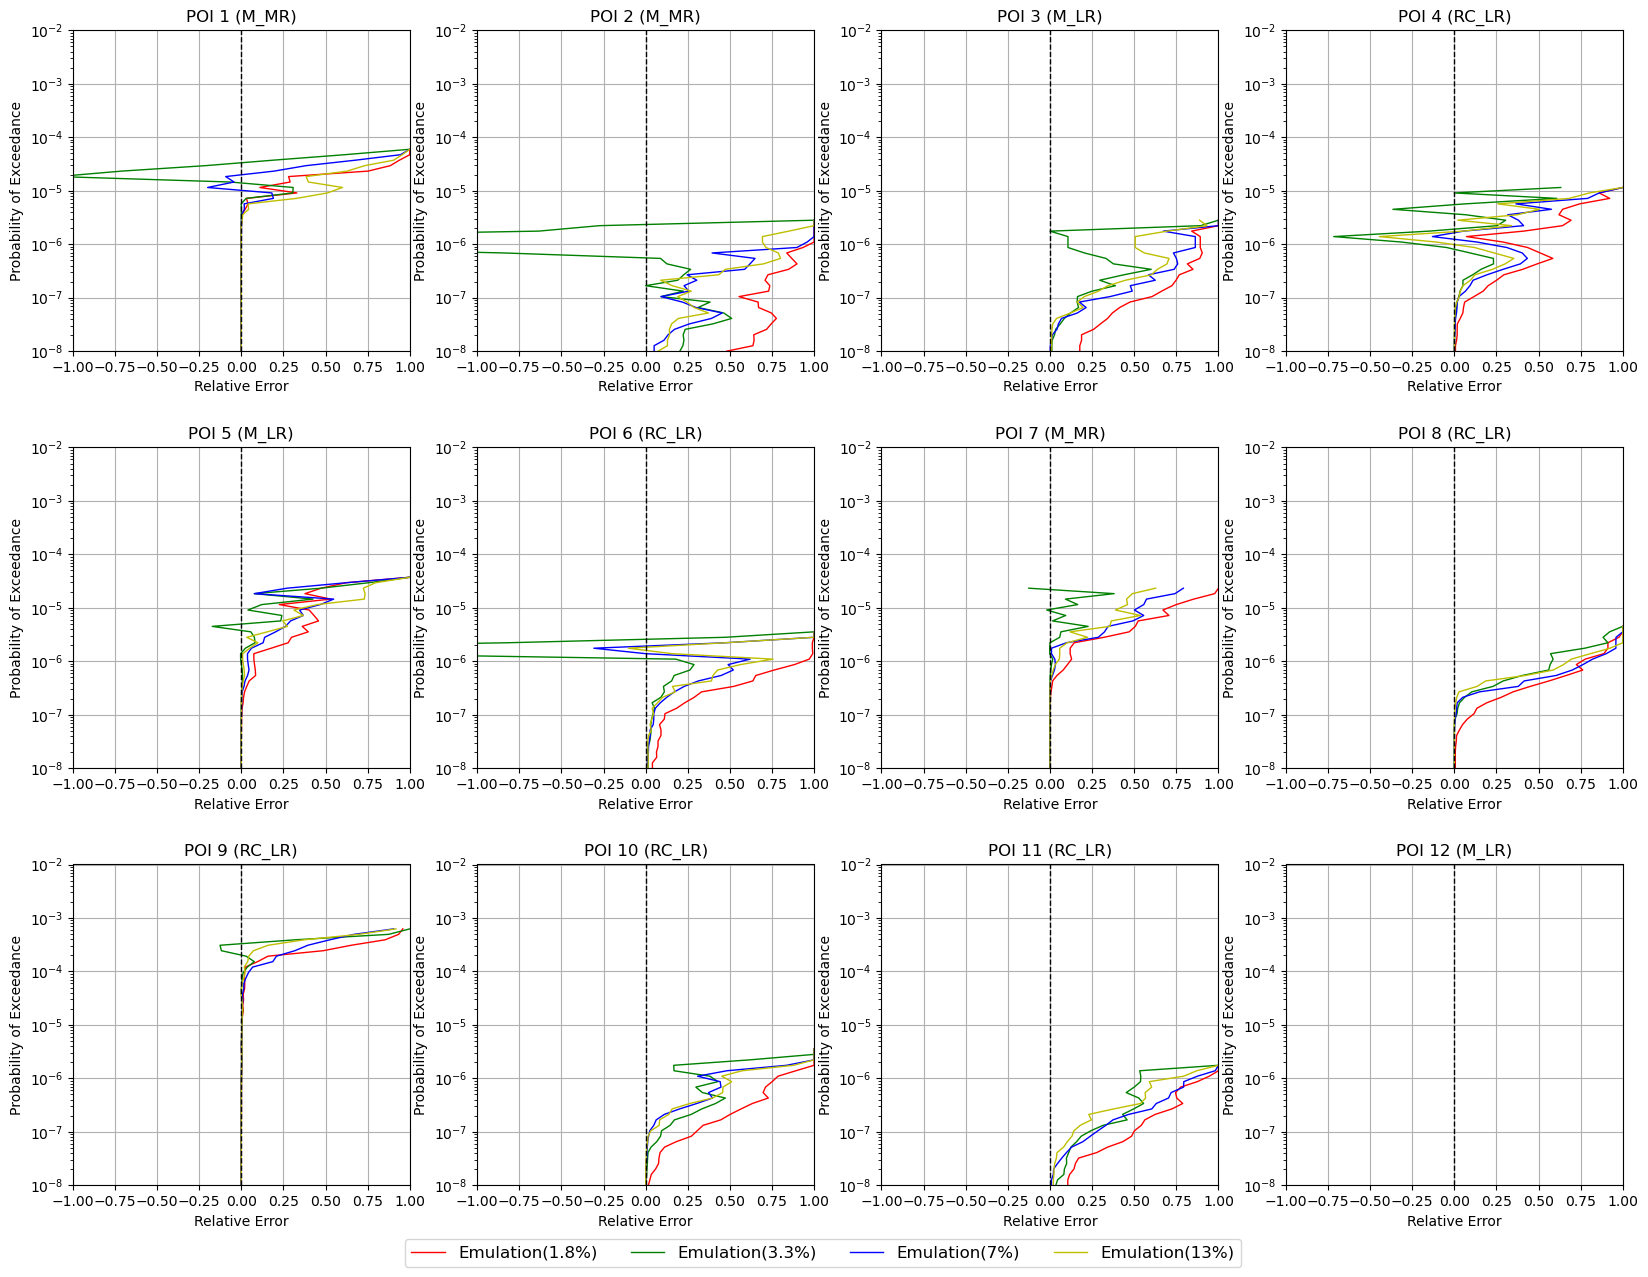

In [18]:
# Initialize a figure with 12 subplots for the 12 sites
fig, axes = plt.subplots(3, 4, figsize=(20, 15))  # 3 rows, 4 columns
fig.subplots_adjust(hspace=0.3, wspace=0.2)

# Loop through the 12 sites
for idx, select_pt in enumerate(IDAG[:12]):  # Adjust to process only the first 12 sites
    index = Control_IDAG[Control_IDAG['IDAG'] == select_pt].index[0]
    pml_true = PMLtrue[PMLtrue.IDAG == select_pt].iloc[:, 3:].values[0]
    pml_0 = PML0[PML0.IDAG == select_pt].iloc[:, 3:].values[0]
    pml_1 = PML1[PML1.IDAG == select_pt].iloc[:, 3:].values[0]
    pml_2 = PML2[PML2.IDAG == select_pt].iloc[:, 3:].values[0]
    pml_3 = PML3[PML3.IDAG == select_pt].iloc[:, 3:].values[0]
    
    # Compute relative errors
    rel_error_0 = (pml_true - pml_0) / pml_true
    rel_error_1 = (pml_true - pml_1) / pml_true
    rel_error_2 = (pml_true - pml_2) / pml_true
    rel_error_3 = (pml_true - pml_3) / pml_true
    
    # Get building class
    building_class = exposure[exposure.IDAG == select_pt]['Building_Class'].values[0]
    
    # Determine subplot position
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    
    # Plot PML exceedance curve
    ax.plot(RP, pml_true, label='HPC-Based', color='k', linewidth=1.5)
    ax.plot(RP, pml_0, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(RP, pml_1, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(RP, pml_2, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(RP, pml_3, label='Emulation(13%)', color='y', linewidth=1)
    
    # Plot settings
    ax.set_title(f'POI {index+1} ({building_class})')
    ax.set_xlabel('Return Period (Years)')
    ax.set_ylabel('PML (Ratio)')
    ax.set_xscale('log')
    ax.set_xlim(1e3, 1e8)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.05),  # Move legend closer to the subplots
)

# Save the figure
plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_all_sites.png')
plt.show()

# Initialize another figure for relative errors
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.subplots_adjust(hspace=0.3, wspace=0.2)

# Loop for relative error subplots
for idx, select_pt in enumerate(IDAG[:12]):
    index = Control_IDAG[Control_IDAG['IDAG'] == select_pt].index[0]
    pml_true = PMLtrue[PMLtrue.IDAG == select_pt].iloc[:, 3:].values[0]
    pml_0 = PML0[PML0.IDAG == select_pt].iloc[:, 3:].values[0]
    pml_1 = PML1[PML1.IDAG == select_pt].iloc[:, 3:].values[0]
    pml_2 = PML2[PML2.IDAG == select_pt].iloc[:, 3:].values[0]
    pml_3 = PML3[PML3.IDAG == select_pt].iloc[:, 3:].values[0]
    
    rel_error_0 = (pml_true - pml_0) / pml_true
    rel_error_1 = (pml_true - pml_1) / pml_true
    rel_error_2 = (pml_true - pml_2) / pml_true
    rel_error_3 = (pml_true - pml_3) / pml_true
    
    building_class = exposure[exposure.IDAG == select_pt]['Building_Class'].values[0]
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    
    # Plot relative error curves
    ax.plot(rel_error_0, PoE, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(rel_error_1, PoE, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(rel_error_2, PoE, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(rel_error_3, PoE, label='Emulation(13%)', color='y', linewidth=1)
    
    # Plot settings
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'POI {index+1} ({building_class})')
    ax.set_ylabel('Probability of Exceedance')
    ax.set_xlabel('Relative Error')
    ax.set_yscale('log')
    ax.set_xlim(-1, 1)
    ax.set_ylim(1e-8, 1e-2)
    ax.grid(True)

# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.05),  # Move legend closer to the subplots
)

# Save the figure
plt.savefig(f'{MLDir}/risk/plots/risk_compare/rel_error_all_sites.png')
plt.show()


/tmp/ipykernel_52340/2615565105.py:10: RuntimeWarning: invalid value encountered in divide
  rel_error_0 = (pml_true - pml_0)/pml_true
/tmp/ipykernel_52340/2615565105.py:11: RuntimeWarning: invalid value encountered in divide
  rel_error_1 = (pml_true - pml_1)/pml_true
/tmp/ipykernel_52340/2615565105.py:12: RuntimeWarning: invalid value encountered in divide
  rel_error_2 = (pml_true - pml_2)/pml_true
/tmp/ipykernel_52340/2615565105.py:13: RuntimeWarning: invalid value encountered in divide
  rel_error_3 = (pml_true - pml_3)/pml_true


19087015000001342700 0


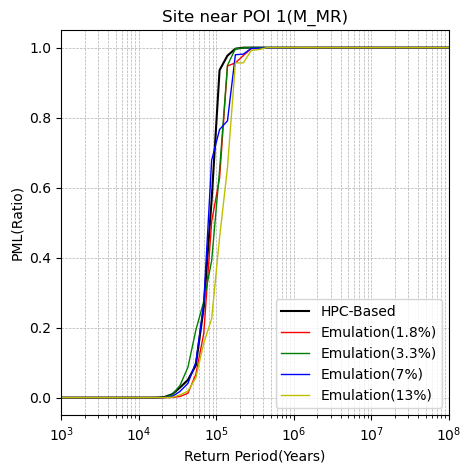

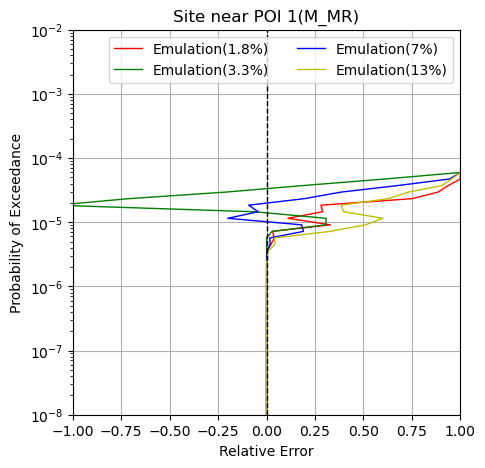

19087015000001962900 1


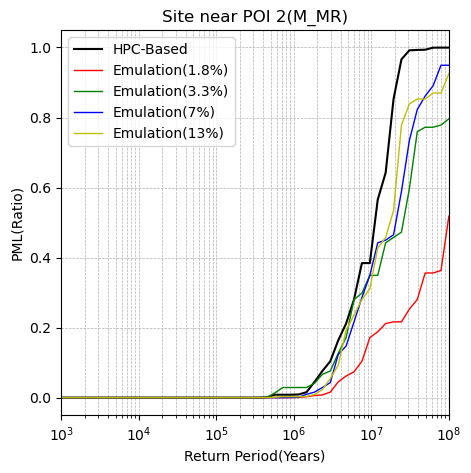

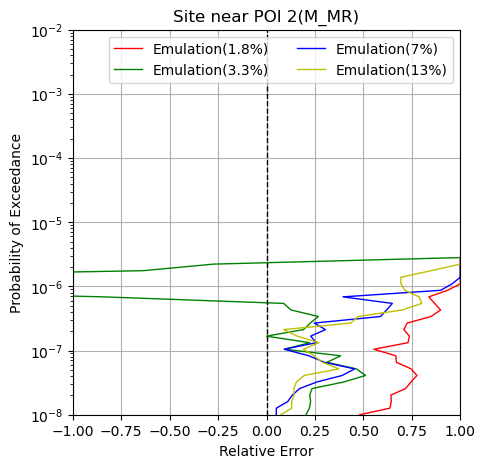

19087015000001669800 2


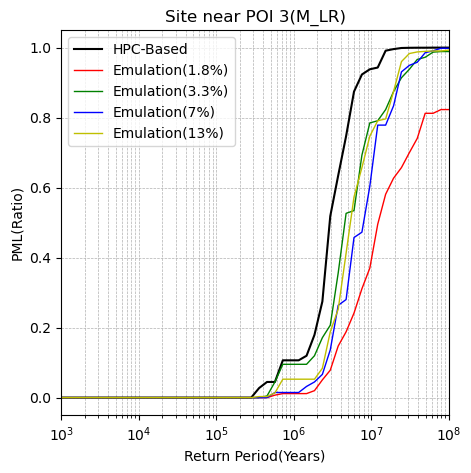

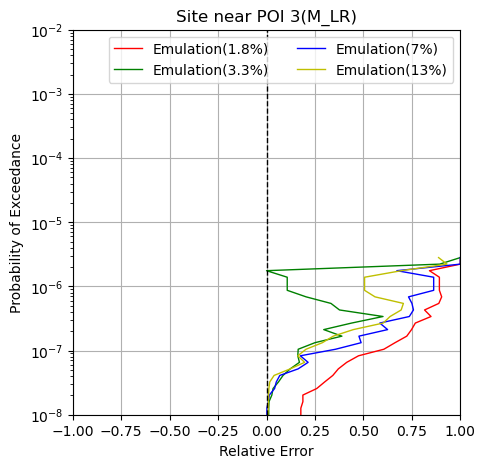

19087015000001947900 3


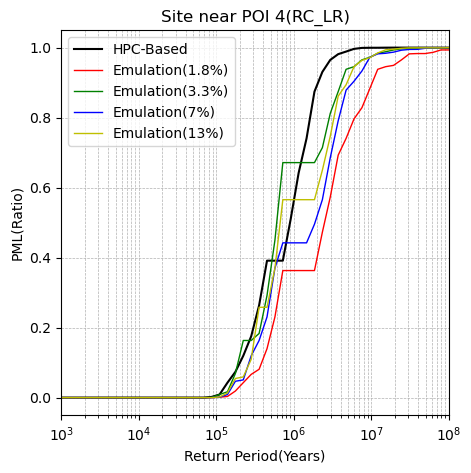

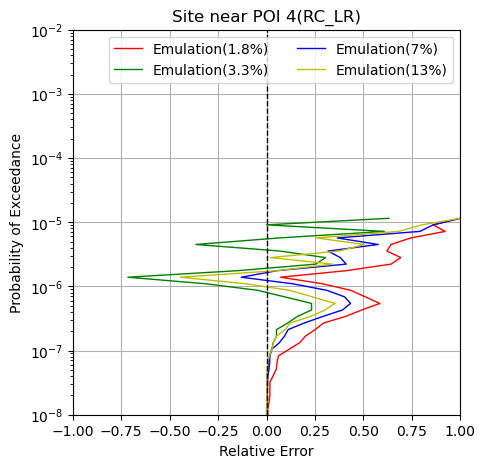

19087015000001960000 4


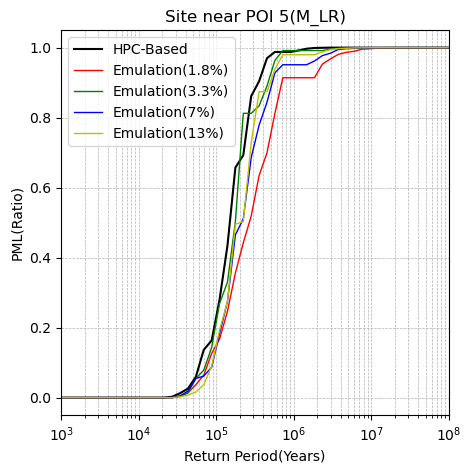

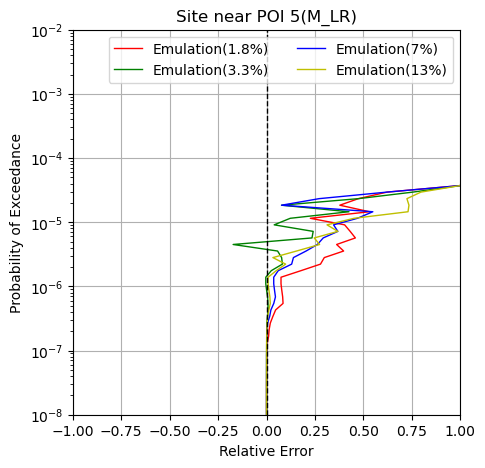

19087015000001794600 5


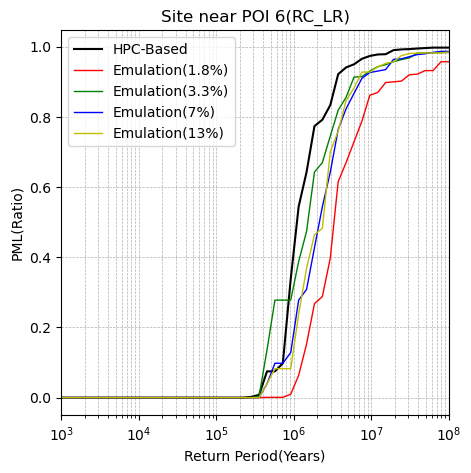

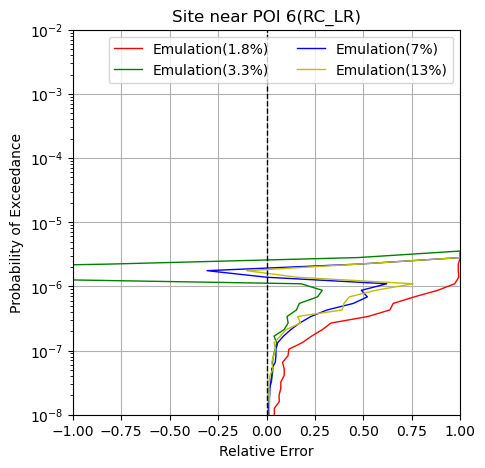

19087015000002227900 6


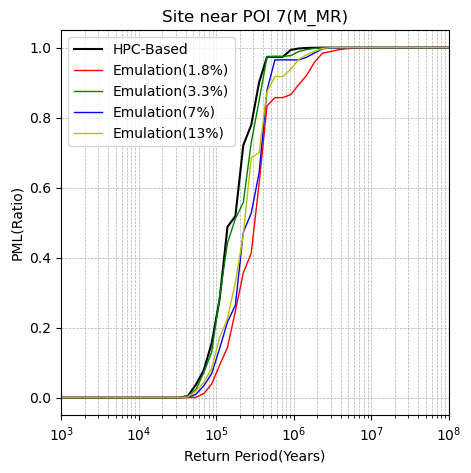

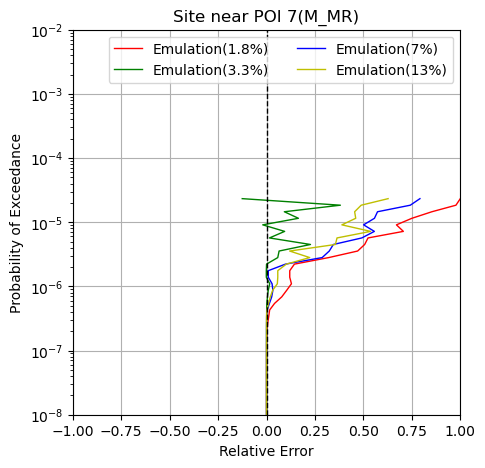

19087015000002086800 7


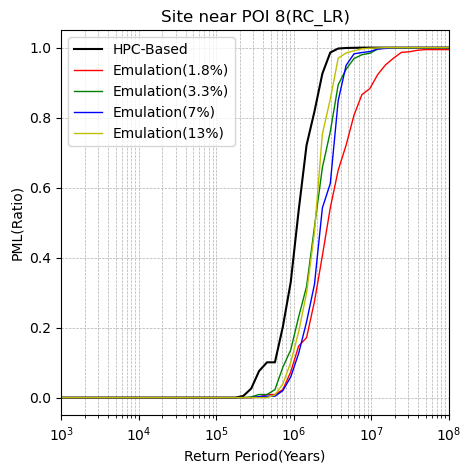

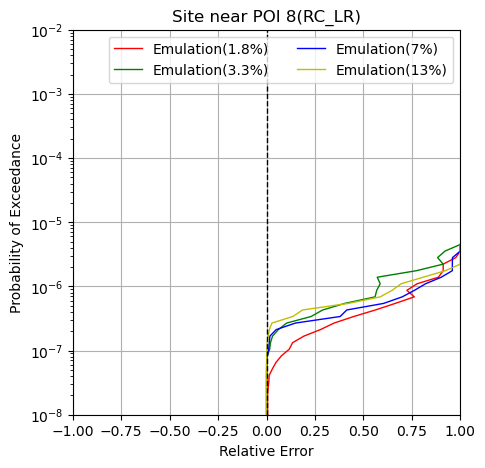

19087015000000183100 8


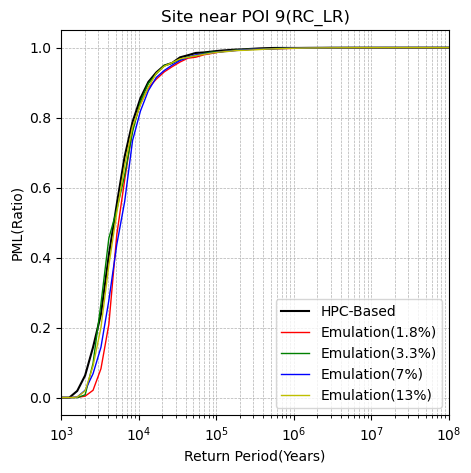

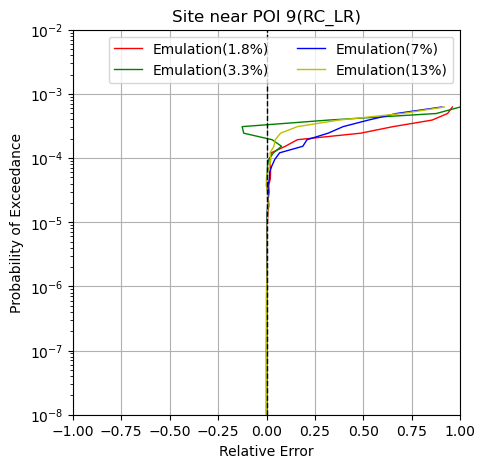

19089006000000263400 9


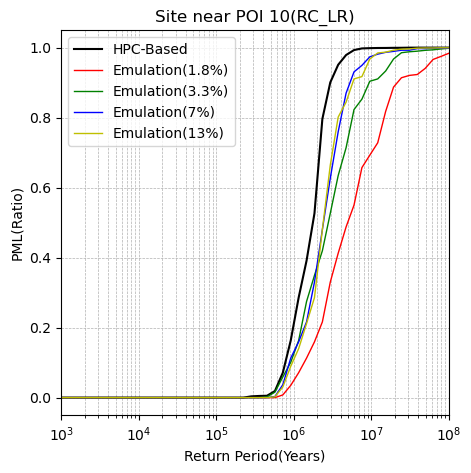

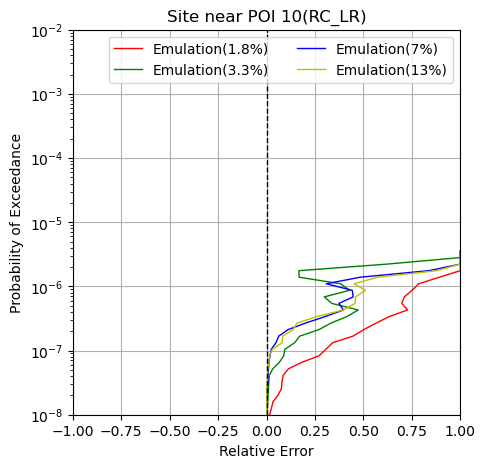

19089001000000035900 10


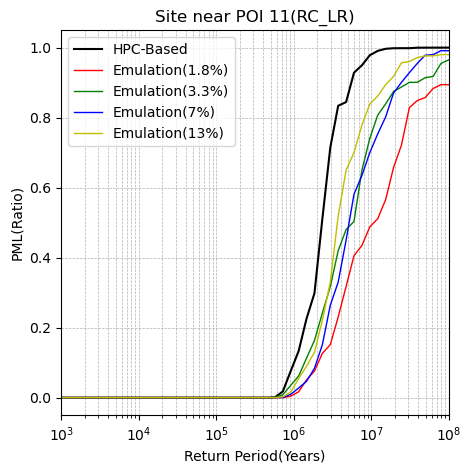

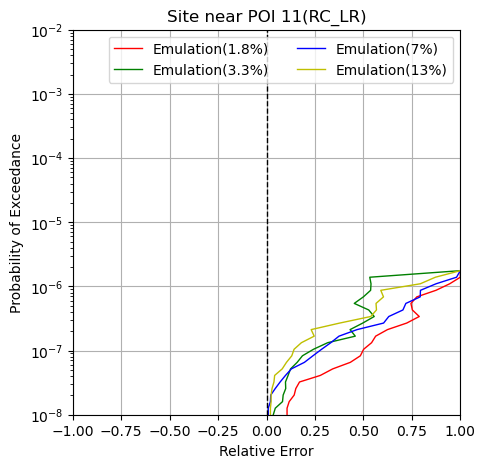

19087015000002073100 11


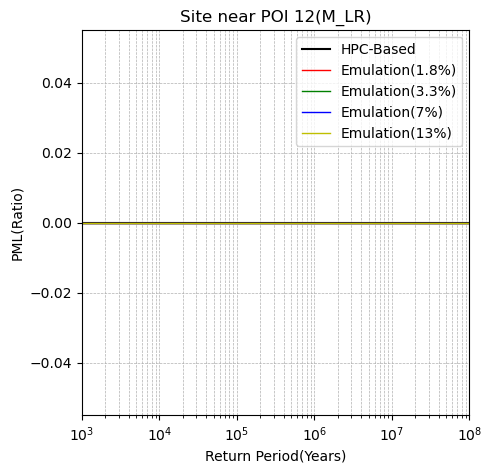

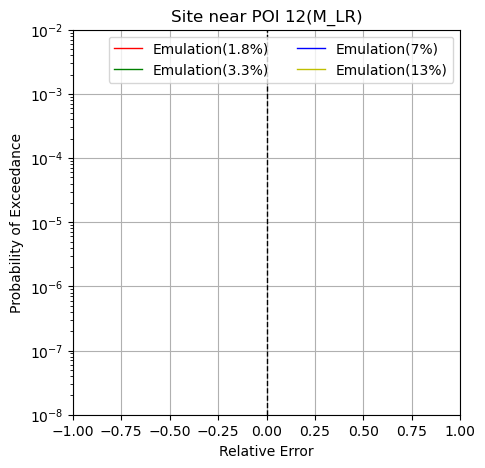

In [ ]:
for select_pt in IDAG:
    index = Control_IDAG[Control_IDAG['IDAG'] == select_pt].index[0]
    pml_true = PMLtrue[PMLtrue.IDAG ==  select_pt].iloc[:, 3:].values[0]
    pml_0 = PML0[PML0.IDAG ==  select_pt].iloc[:, 3:].values[0]
    pml_1 = PML1[PML1.IDAG ==  select_pt].iloc[:, 3:].values[0]
    pml_2 = PML2[PML2.IDAG ==  select_pt].iloc[:, 3:].values[0]
    pml_3 = PML3[PML3.IDAG ==  select_pt].iloc[:, 3:].values[0]

    #compute relative error for each threshold of return period between predictions and true
    rel_error_0 = (pml_true - pml_0)/pml_true
    rel_error_1 = (pml_true - pml_1)/pml_true
    rel_error_2 = (pml_true - pml_2)/pml_true
    rel_error_3 = (pml_true - pml_3)/pml_true

    #get AAL for each site
    aal_true = AALtrue[AALtrue.IDAG ==  select_pt].iloc[:, 3].values[0]
    aal_0 = AAL0[AAL0.IDAG ==  select_pt].iloc[:, 3].values[0]
    aal_1 = AAL1[AAL1.IDAG ==  select_pt].iloc[:, 3].values[0]
    aal_2 = AAL2[AAL2.IDAG ==  select_pt].iloc[:, 3].values[0]
    aal_3 = AAL3[AAL3.IDAG ==  select_pt].iloc[:, 3].values[0]

    #building class
    building_class = exposure[exposure.IDAG == select_pt]['Building_Class'].values[0]

    print(select_pt, index)
    #plot exceedance curve and relative error for each site
    plt.figure(figsize=(5, 5))
    plt.plot(RP,pml_true,label='HPC-Based', color='k',linewidth=1.5)
    plt.plot(RP,pml_0,label='Emulation(1.8%)', color='r',linewidth=1)
    plt.plot(RP,pml_1,label='Emulation(3.3%)', color='g',linewidth=1)
    plt.plot(RP,pml_2,label='Emulation(7%)', color='b',linewidth=1)
    plt.plot(RP,pml_3,label='Emulation(13%)', color='y',linewidth=1)

    # draw line exceed threshold probability of 1e-4, 1e-6, 1e-8
    # plt.axhline(y=t[0], color='grey', linestyle='--')
    # plt.axhline(y=t[1], color='grey', linestyle='--')
    
    # #get nevents exceeding threshold probability of 1e-4, 1e-6, 1e-8 depths
    # ncount = exceedance_count(true, thresholds_depth, lambda_exc_true,t)
    # plt.text(8, 3*(1e-4), '#'+str(eve_dep_0.shape[0]-sum(ncount))+'/'+str(eve_dep_0.shape[0]), color='k')
    # plt.text(8, (1e-5), '#'+str(ncount[0])+'/'+str(eve_dep_0.shape[0]), color='k')
    # plt.text(8, 3*(1e-7), '#'+str(ncount[1])+'/'+str(eve_dep_0.shape[0]), color='k')

    plt.xlabel('Return Period(Years)')
    plt.ylabel('PML(Ratio)')
    plt.xscale('log')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    # plt.ylim(1e-8, 1)
    plt.xlim(1e3, 1e8)
    plt.legend(ncol=1) 
    plt.title(f'Site near POI {index+1}({building_class})')
    plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_{index+1}_all.png')
    plt.show()

    #plot exceedance curve
    plt.figure(figsize=(5, 5))
    plt.plot(rel_error_0,PoE, label='Emulation(1.8%)', color='r',linewidth=1)
    plt.plot(rel_error_1,PoE, label='Emulation(3.3%)', color='g',linewidth=1)
    plt.plot(rel_error_2,PoE, label='Emulation(7%)', color='b',linewidth=1)
    plt.plot(rel_error_3,PoE, label='Emulation(13%)', color='y',linewidth=1)
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.ylabel('Probability of Exceedance')
    plt.xlabel('Relative Error')
    plt.yscale('log')
    plt.grid(True)
    plt.xlim(-1, 1)
    plt.ylim(1e-8,1e-2)
    plt.legend(ncol=2)
    plt.title(f'Site near POI {index+1}({building_class})')
    plt.savefig(f'{MLDir}/risk/plots/risk_compare/risk_rel_err_{index+1}_all.png')
    plt.show()


Portfolio Level

In [94]:
def get_loss_pml(loss,rate,threshold,PoE,total_value = 28491684200,t = [1e-4,1e-6,1e-8]):
    
    #filter events based on threshold of 500
    # print('Number of events before filtering:', len(loss))
    rate = rate[loss>threshold]
    loss = loss[loss>threshold]
    # print('Number of events after filtering:', len(loss))

    #reset index
    rate = rate.reset_index(drop=True)
    loss = loss.reset_index(drop=True)

    #sort descending
    idx = np.argsort(loss)[::-1]
    sorted_loss = loss[idx]
    sorted_rate = rate[idx]  
    
    #Event loss table
    ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
    ELT['weighted_loss'] = sorted_loss*sorted_rate
    ELT['cumulative_probability'] = ELT['rate'].cumsum()

    AAL = np.sum(ELT['weighted_loss'])
    print('AAL:',AAL,'\n')

    PML = np.zeros(len(PoE))
    PML_ratio = np.zeros(len(PoE))

    if total_value ==  28491684200:
        print('Warning, using default portfolio exposure value of 2.8e10')

    #find the event loss for each RP
    for i,probability_level in enumerate(PoE):
        # print(probability_level,len(ELT['loss'][ELT['cumulative_probability']>probability_level]))
        PML[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()
        if PML[i] == np.nan:
            PML_ratio[i] = 0
        else:
            PML_ratio[i] = PML[i]/total_value

    #get count of events exceeding threshold probability t 
    ncount = []
    for i,prob in enumerate(t):
        neve = len(ELT['loss'][ELT['cumulative_probability']<prob])
        ncount.append(neve)     
    return PML,PML_ratio,ELT,AAL,ncount


In [95]:
#read event_info_agg_loss.csv
event_info = pd.read_csv(f'{MLDir}/risk/results/3_event_info_agg_loss.csv',header=0)

AAL: 20169.989239660295 

Warning, using default portfolio exposure value of 2.8e10
AAL: 14583.916800502835 

Warning, using default portfolio exposure value of 2.8e10


AAL: 18543.52825523648 

Warning, using default portfolio exposure value of 2.8e10
AAL: 15929.3439419328 

Warning, using default portfolio exposure value of 2.8e10
AAL: 16446.225653797777 

Warning, using default portfolio exposure value of 2.8e10
AAL: 20169.989239660295 

Warning, using default portfolio exposure value of 2.8e10


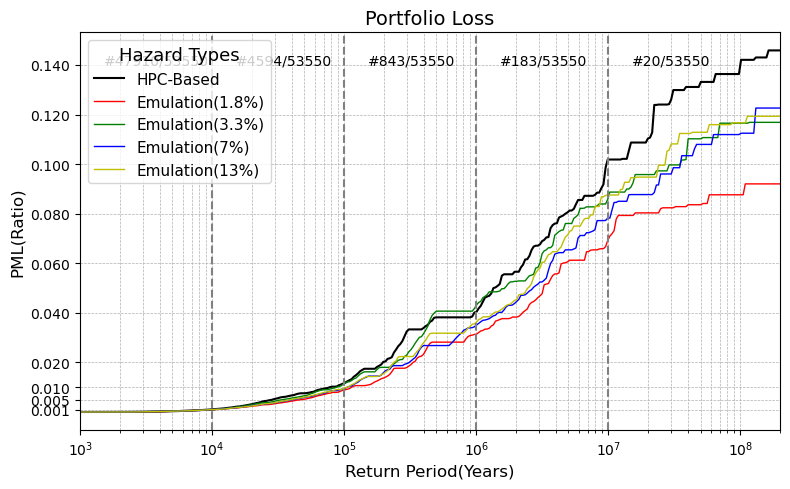

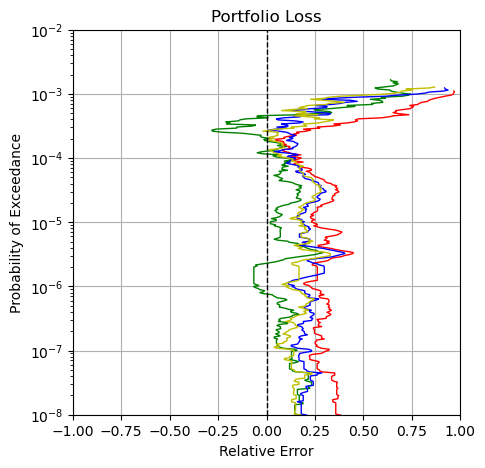

In [96]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = np.logspace(1, 9, num=500, base=10)

PoE = [1/rp for rp in RP]

min_loss = 500

PML_true = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE)[1]
PML_892 = get_loss_pml(event_info['loss_892'],event_info['mean_prob'],min_loss,PoE)[1]
PML_1658 = get_loss_pml(event_info['loss_1658'],event_info['mean_prob'],min_loss,PoE)[1]
PML_3454 = get_loss_pml(event_info['loss_3454'],event_info['mean_prob'],min_loss,PoE)[1]
PML_7071 = get_loss_pml(event_info['loss_7071'],event_info['mean_prob'],min_loss,PoE)[1]


rel_error_0 = (PML_true - PML_892)/PML_true
rel_error_1 = (PML_true - PML_1658)/PML_true
rel_error_2 = (PML_true - PML_3454)/PML_true
rel_error_3 = (PML_true - PML_7071)/PML_true

#plot
fig, ax = plt.subplots(figsize=(8, 5))

# Use a professional color palette
colors = ['k', 'r', 'g', 'b', 'y']

ax.plot(RP, PML_true, label='HPC-Based', color=colors[0], linewidth=1.5)
ax.plot(RP, PML_892, label='Emulation(1.8%)', color=colors[1], linewidth=1)
ax.plot(RP, PML_1658, label='Emulation(3.3%)', color=colors[2], linewidth=1)
ax.plot(RP, PML_3454, label='Emulation(7%)', color=colors[3], linewidth=1)
ax.plot(RP, PML_7071, label='Emulation(13%)', color=colors[4], linewidth=1)

#get nevents exceeding threshold probability of 1e-4, 1e-6, 1e-8 depths
total_value = 28491684200
t = [1e-4,1e-5,1e-6,1e-7,1e-8]
ncount = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE,total_value,t)[-1]
#get counts of events exceeding threshold probability of 1e-4, 1e-6, 1e-8
ax.text(1.5*(1e3),0.14, '#'+str(event_info.shape[0]-ncount[0])+'/'+str(event_info.shape[0]), color='k')
ax.text(1.5*(1e4),.14, '#'+str(ncount[0]-ncount[1])+'/'+str(event_info.shape[0]), color='k')
ax.text(1.5*(1e5),.14, '#'+str(ncount[1]-ncount[2])+'/'+str(event_info.shape[0]), color='k')
ax.text(1.5*(1e6),.14, '#'+str(ncount[2]-ncount[3])+'/'+str(event_info.shape[0]), color='k')
ax.text(1.5*(1e7),.14, '#'+str(ncount[3])+'/'+str(event_info.shape[0]), color='k')

#draw vertical line exceed threshold probability of 1e4, 1e6, 1e8
ax.axvline(x=1e4, color='grey', linestyle='--')
ax.axvline(x=1e5, color='grey', linestyle='--')
ax.axvline(x=1e6, color='grey', linestyle='--')
ax.axvline(x=1e7, color='grey', linestyle='--')


ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Return Period(Years)', fontsize=12)
ax.set_ylabel('PML(Ratio)', fontsize=12)
ax.set_title('Portfolio Loss', fontsize=14)
ax.set_xlim(1e3, 2e8)
# ax.set_ylim(1e-5, 2e-1)
ax.set_yticks([0.001, 0.005, 0.01, 0.02, 0.04,.06,.08,.1,.12,.14]) 
# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend
ax.legend(title='Hazard Types', title_fontsize='13', fontsize='11')

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Show plot
plt.tight_layout()
plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_portfolio.png')
plt.show()

#plot exceedance curve
plt.figure(figsize=(5, 5))
plt.plot(rel_error_0,PoE, label='Emulation(1.8%)', color='r',linewidth=1)
plt.plot(rel_error_1,PoE, label='Emulation(3.3%)', color='g',linewidth=1)
plt.plot(rel_error_2,PoE, label='Emulation(7%)', color='b',linewidth=1)
plt.plot(rel_error_3,PoE, label='Emulation(13%)', color='y',linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.ylabel('Probability of Exceedance')
plt.xlabel('Relative Error')
plt.yscale('log')
plt.grid(True)
plt.xlim(-1, 1)
plt.ylim(1e-8,1e-2)
# plt.legend(ncol=2)
plt.title(f'Portfolio Loss')
plt.savefig(f'{MLDir}/risk/plots/risk_compare/risk_rel_err_portfolio.png')
plt.show()



Construction Types

/tmp/ipykernel_3444078/1890520245.py:28: RuntimeWarning: invalid value encountered in divide
  rel_error_0 = (pml_true - pml_0) / pml_true
/tmp/ipykernel_3444078/1890520245.py:29: RuntimeWarning: invalid value encountered in divide
  rel_error_1 = (pml_true - pml_1) / pml_true
/tmp/ipykernel_3444078/1890520245.py:30: RuntimeWarning: invalid value encountered in divide
  rel_error_2 = (pml_true - pml_2) / pml_true
/tmp/ipykernel_3444078/1890520245.py:31: RuntimeWarning: invalid value encountered in divide
  rel_error_3 = (pml_true - pml_3) / pml_true


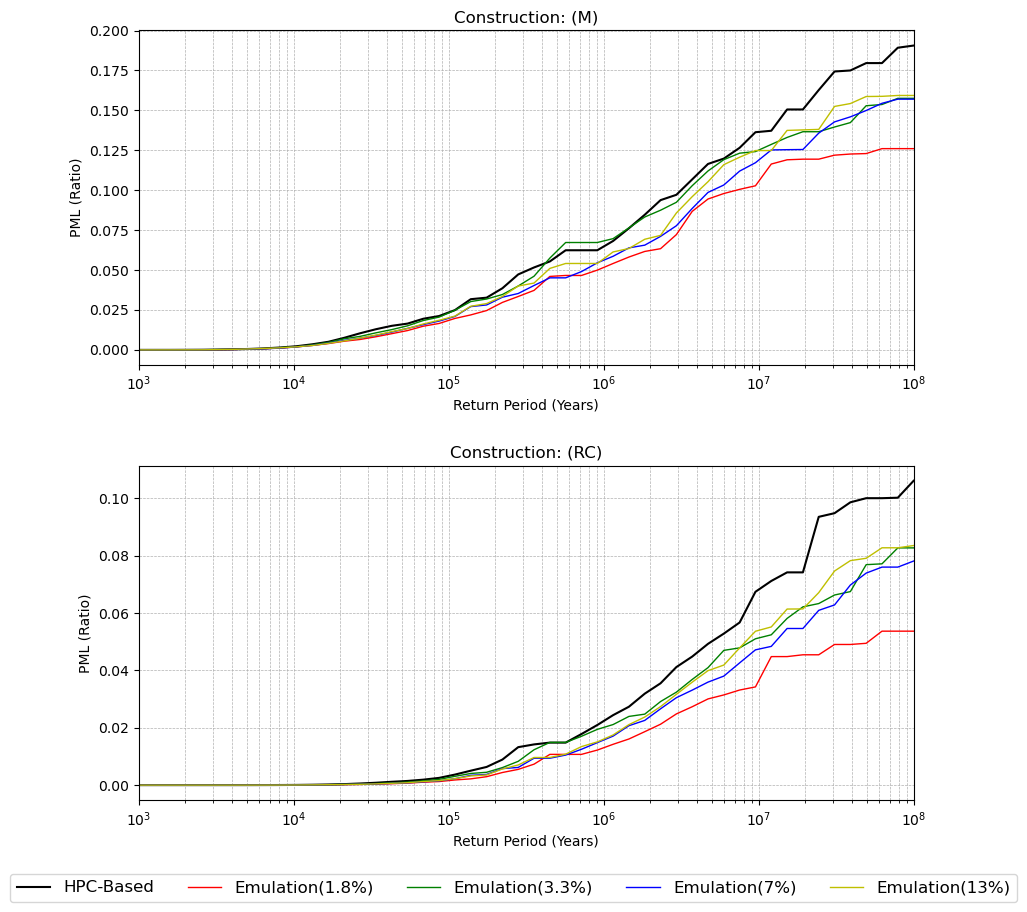

/tmp/ipykernel_3444078/1890520245.py:78: RuntimeWarning: invalid value encountered in divide
  rel_error_0 = (pml_true - pml_0) / pml_true
/tmp/ipykernel_3444078/1890520245.py:79: RuntimeWarning: invalid value encountered in divide
  rel_error_1 = (pml_true - pml_1) / pml_true
/tmp/ipykernel_3444078/1890520245.py:80: RuntimeWarning: invalid value encountered in divide
  rel_error_2 = (pml_true - pml_2) / pml_true
/tmp/ipykernel_3444078/1890520245.py:81: RuntimeWarning: invalid value encountered in divide
  rel_error_3 = (pml_true - pml_3) / pml_true


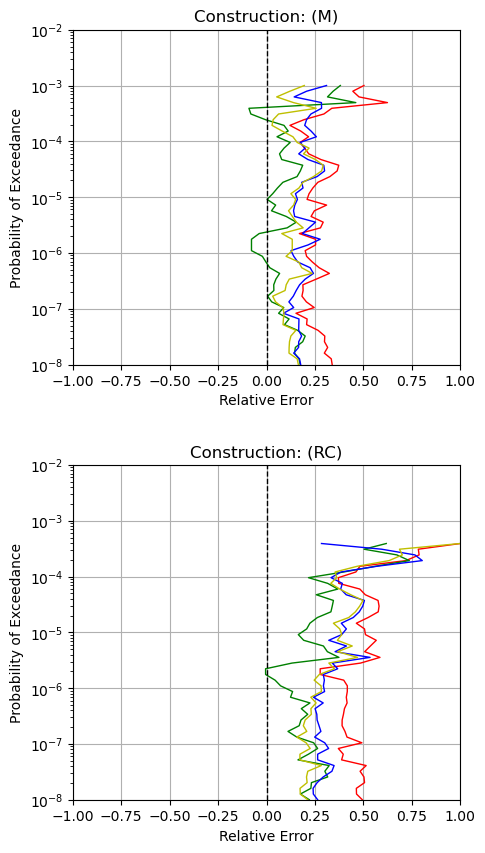

In [118]:
PMLtrue = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_const_true.csv')
PML0 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_const_{list_size[0]}.csv')
PML1 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_const_{list_size[1]}.csv')
PML2 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_const_{list_size[2]}.csv')
PML3 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_const_{list_size[3]}.csv')

AALtrue = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_const_true.csv')
AAL0 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_const_{list_size[0]}.csv')
AAL1 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_const_{list_size[1]}.csv')
AAL2 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_const_{list_size[2]}.csv')
AAL3 = pd.read_csv(f'{MLDir}/risk/results/risk_calc/5_AAL_table_const_{list_size[3]}.csv')

ConstType = ['M','RC']
# Initialize a figure with 12 subplots for the 12 sites
fig, axes = plt.subplots(2, 1, figsize=(10, 10))  # 3 rows, 4 columns
axes = axes.flatten()
fig.subplots_adjust(hspace=0.3, wspace=0.2)

# Loop through the 12 sites
for idx, select_pt in enumerate(ConstType):  # Adjust to process only the first 12 sites
    pml_true = PMLtrue[PMLtrue.const_id == select_pt].iloc[:, 3:].values[0]
    pml_0 = PML0[PML0.const_id == select_pt].iloc[:, 3:].values[0]
    pml_1 = PML1[PML1.const_id == select_pt].iloc[:, 3:].values[0]
    pml_2 = PML2[PML2.const_id == select_pt].iloc[:, 3:].values[0]
    pml_3 = PML3[PML3.const_id == select_pt].iloc[:, 3:].values[0]
    
    # Compute relative errors
    rel_error_0 = (pml_true - pml_0) / pml_true
    rel_error_1 = (pml_true - pml_1) / pml_true
    rel_error_2 = (pml_true - pml_2) / pml_true
    rel_error_3 = (pml_true - pml_3) / pml_true
      
    # Determine subplot position
    ax = axes[idx]
    # Plot PML exceedance curve
    ax.plot(RP, pml_true, label='HPC-Based', color='k', linewidth=1.5)
    ax.plot(RP, pml_0, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(RP, pml_1, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(RP, pml_2, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(RP, pml_3, label='Emulation(13%)', color='y', linewidth=1)
    
    # Plot settings
    ax.set_title(f'Construction: ({select_pt})')
    ax.set_xlabel('Return Period (Years)')
    ax.set_ylabel('PML (Ratio)')
    ax.set_xscale('log')
    ax.set_xlim(1e3, 1e8)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.0),  # Move legend closer to the subplots
)

# Save the figure
plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_const.png')
plt.show()

# Initialize another figure for relative errors
fig, axes = plt.subplots(2, 1, figsize=(5, 10))
axes = axes.flatten()
fig.subplots_adjust(hspace=0.3, wspace=0.2)

# Loop for relative error subplots
for idx, select_pt in enumerate(ConstType):
    pml_true = PMLtrue[PMLtrue.const_id == select_pt].iloc[:, 3:].values[0]
    pml_0 = PML0[PML0.const_id == select_pt].iloc[:, 3:].values[0]
    pml_1 = PML1[PML1.const_id == select_pt].iloc[:, 3:].values[0]
    pml_2 = PML2[PML2.const_id == select_pt].iloc[:, 3:].values[0]
    pml_3 = PML3[PML3.const_id == select_pt].iloc[:, 3:].values[0]
    
    rel_error_0 = (pml_true - pml_0) / pml_true
    rel_error_1 = (pml_true - pml_1) / pml_true
    rel_error_2 = (pml_true - pml_2) / pml_true
    rel_error_3 = (pml_true - pml_3) / pml_true
    
    ax = axes[idx]
    
    # Plot relative error curves
    ax.plot(rel_error_0, PoE, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(rel_error_1, PoE, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(rel_error_2, PoE, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(rel_error_3, PoE, label='Emulation(13%)', color='y', linewidth=1)
    
    # Plot settings
    ax.set_title(f'Construction: ({select_pt})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Probability of Exceedance')
    ax.set_xlabel('Relative Error')
    ax.set_yscale('log')
    ax.set_xlim(-1, 1)
    ax.set_ylim(1e-8, 1e-2)
    ax.grid(True)

# Save the figure
plt.savefig(f'{MLDir}/risk/plots/risk_compare/risk_rel_error_const.png')
plt.show()


Risk Sensitivity

Index: 10 PoE: 9.540954763499945e-05


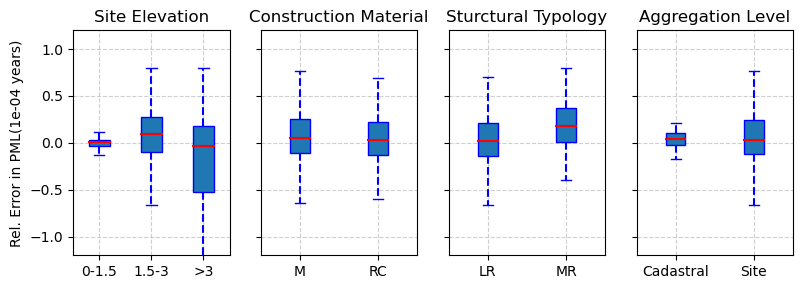

Index: 20 PoE: 9.102981779915228e-06


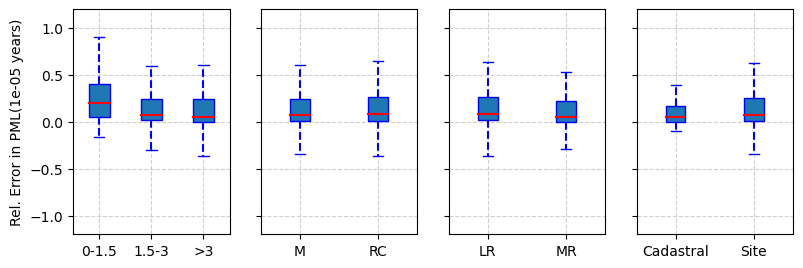

Index: 29 PoE: 1.0985411419875572e-06


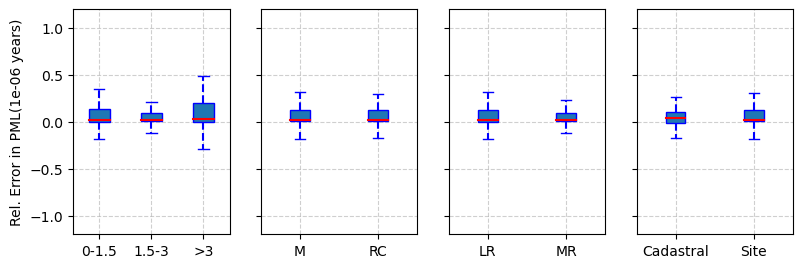

Index: 39 PoE: 1.0481131341546853e-07


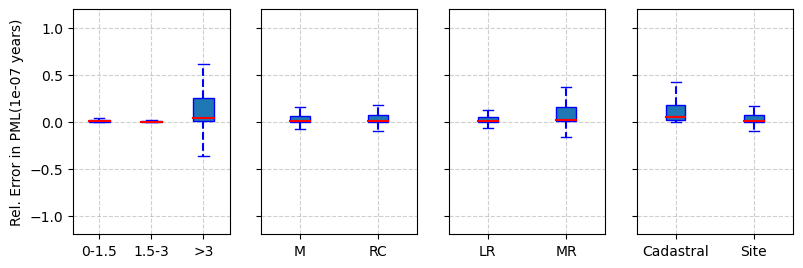

Index: 49 PoE: 1e-08


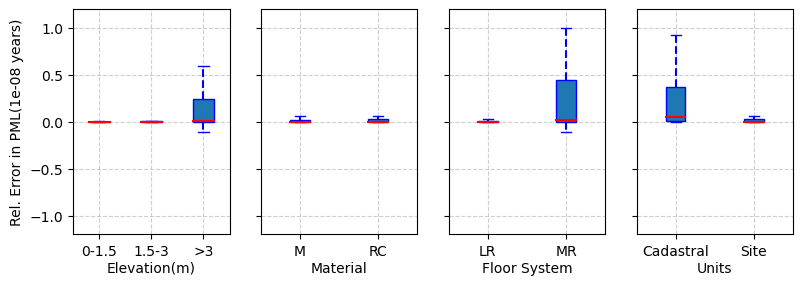

In [37]:
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
import numpy as np
import seaborn as sns
# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
t = [1e-4,1e-5,1e-6,1e-7,1e-8]


for point in t:
    RP = np.logspace(3,8,50,base=10)
    PoE = [1/rp for rp in RP]   
    #Find PoE index closest to 1e-4
    idx = (np.abs(np.array(PoE) - point)).argmin()
    print('Index:',idx,'PoE:',PoE[idx])

    asset_perf_true = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_true.csv')[['agg_id','IDAG','value',f'PoE{idx}']]
    asset_perf_pred = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_1658.csv')[['agg_id','IDAG','value',f'PoE{idx}']]
    asset_perf_true['PML_rel_err'] = (asset_perf_true[f'PoE{idx}'] - asset_perf_pred[f'PoE{idx}']) / asset_perf_true[f'PoE{idx}']
    del asset_perf_pred
    asset_perf_true = asset_perf_true[asset_perf_true[f'PoE{idx}'] > 1e-2]

    foglio_perf_true = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_foglio_true.csv')[['agg_id','foglio_id','value',f'PoE{idx}']]
    foglio_perf_pred = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_foglio_1658.csv')[['agg_id','foglio_id','value',f'PoE{idx}']]
    foglio_perf_true['PML_rel_err'] = (foglio_perf_true[f'PoE{idx}'] - foglio_perf_pred[f'PoE{idx}']) / foglio_perf_true[f'PoE{idx}']
    del foglio_perf_pred
    foglio_perf_true = foglio_perf_true[foglio_perf_true[f'PoE{idx}'] > 1e-2]

    # Merge the two dataframes
    asset_perf_true2 = asset_perf_true.copy()
    asset_perf_true2['IDAG'] = 'site'
    asset_perf_true2.columns = ['agg_id','level','value','PoE','PML_rel_err']
    foglio_perf_true['foglio_id'] = 'foglio'
    foglio_perf_true.columns = ['agg_id','level','value','PoE','PML_rel_err']
    combined_perf_true = pd.concat([asset_perf_true2, foglio_perf_true], ignore_index=True)

    # Merge the two dataframes using the 'IDAG' column
    exposure = pd.read_csv(f'{MLDir}/risk/loss/building_exposure.csv')
    asset_perf_true = pd.merge(asset_perf_true, exposure, on='IDAG', how='inner')

    #Catergories - Construction Type(M or RC), Floor Type(LR,MR,HR), Elevation(0-1.5,1.5-3,3), 
    ele_edges = [0,1.5,3,10]
    asset_perf_true['ele_bin'] = pd.cut(asset_perf_true['Elevation'], ele_edges)

    fig,axs = plt.subplots(1,4,figsize=(9,3),sharey=True)
    axs = axs.flatten()
    boxprops = dict(linestyle='-', linewidth=1.0, color='blue')
    flierprops = dict(marker='o', color='red', alpha=0.5, markersize=1.5)
    medianprops = dict(linestyle='-', linewidth=1.5, color='red')
    whiskerprops = dict(linestyle='--', linewidth=1.5, color='blue')
    capprops = dict(linestyle='-', linewidth=1.0, color='blue')

    asset_perf_true.boxplot(column='PML_rel_err', by='ele_bin', vert=True, 
                            showfliers=False, widths=0.4, patch_artist=True,
                            boxprops=boxprops, flierprops=flierprops, 
                            medianprops=medianprops, whiskerprops=whiskerprops, 
                            capprops=capprops, ax=axs[0])
      
    xticklabels_elevation = ['0-1.5', '1.5-3', '>3']
    axs[0].set_xticklabels(xticklabels_elevation)

    asset_perf_true.boxplot(column='PML_rel_err', by='Construction', vert=True,
                            showfliers=False, widths=0.25, patch_artist=True,
                            boxprops=boxprops, flierprops=flierprops, 
                            medianprops=medianprops, whiskerprops=whiskerprops, 
                            capprops=capprops, ax=axs[1])

    asset_perf_true.boxplot(column='PML_rel_err', by='FloorType', vert=True,
                            showfliers=False, widths=0.25, patch_artist=True,
                            boxprops=boxprops, flierprops=flierprops, 
                            medianprops=medianprops, whiskerprops=whiskerprops, 
                            capprops=capprops, ax=axs[2])

    combined_perf_true.boxplot(column='PML_rel_err', by='level', vert=True,
                            showfliers=False, widths=0.25, patch_artist=True,
                            boxprops=boxprops, flierprops=flierprops, 
                            medianprops=medianprops, whiskerprops=whiskerprops, 
                            capprops=capprops, ax=axs[3])
    xticklabels_level = ['Cadastral', 'Site']
    axs[3].set_xticklabels(xticklabels_level)

    # Titles for each subplot
    titles = ['Site Elevation','Construction Material','Sturctural Typology','Aggregation Level']
    xaxis_label= ['Elevation(m)','Material','Floor System','Units']

    # Set the titles for each subplot
    for i, ax in enumerate(axs):
        if point == t[0]:
            ax.set_title(titles[i])
        else:
            ax.set_title('')
        #set ticks 0-1
        # ax.set_xticks(np.arange(0,1.1,0.2))
        ax.set_xlabel(None)
        if point == t[-1]:
                ax.text(0.5,-0.15,xaxis_label[i],rotation=0,va='center',ha='center',transform=ax.transAxes)
        ax.grid(axis='x', linestyle='--', alpha=0.6)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.set_ylim(-1.2,1.2)
    axs[0].set_ylabel(f'Rel. Error in PML({point:.0e} years)')
    
    # # Adjust the layout to prevent overlap
    # plt.tight_layout(pad=0, w_pad=0.5, h_pad=0.5)
    # # Set the main title for the figure
    fig.suptitle(None)

    # # Display the plot
    plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_sensitivity_PoE{point:.0e}.png')
    plt.show()

Index: 10 PoE: 9.540954763499945e-05


/tmp/ipykernel_3444078/2947217400.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(xticklabels_elevation)
/tmp/ipykernel_3444078/2947217400.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[3].set_xticklabels(xticklabels_level)


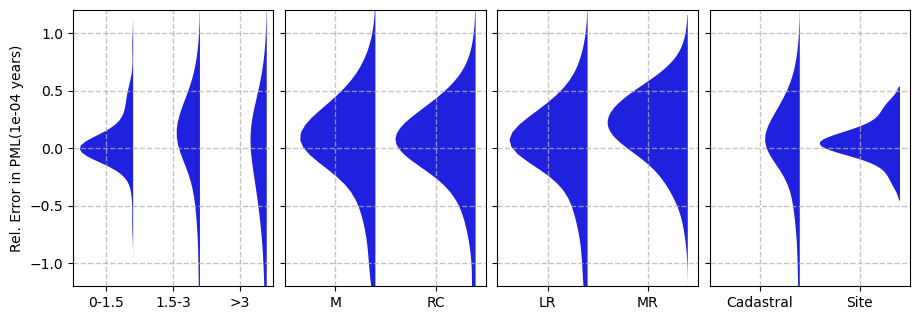

Index: 20 PoE: 9.102981779915228e-06


/tmp/ipykernel_3444078/2947217400.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(xticklabels_elevation)
/tmp/ipykernel_3444078/2947217400.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[3].set_xticklabels(xticklabels_level)


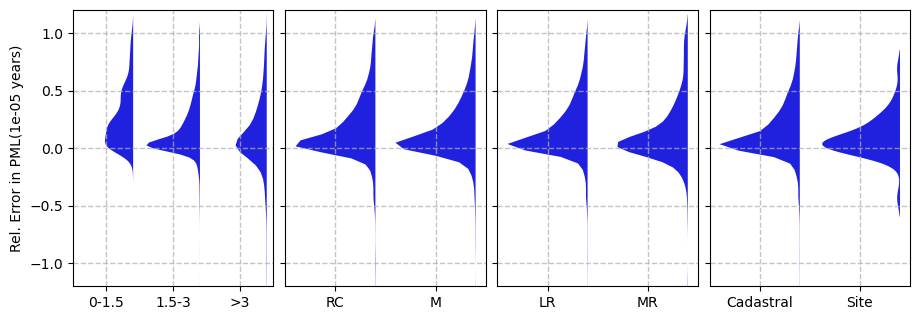

Index: 29 PoE: 1.0985411419875572e-06


/tmp/ipykernel_3444078/2947217400.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(xticklabels_elevation)
/tmp/ipykernel_3444078/2947217400.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[3].set_xticklabels(xticklabels_level)


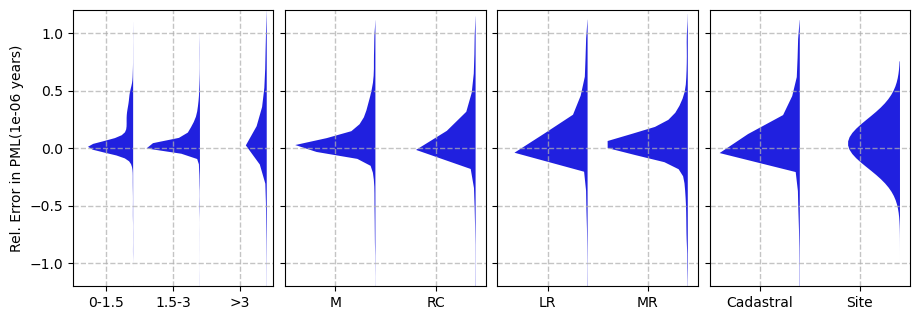

Index: 39 PoE: 1.0481131341546853e-07


/tmp/ipykernel_3444078/2947217400.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(xticklabels_elevation)
/tmp/ipykernel_3444078/2947217400.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[3].set_xticklabels(xticklabels_level)


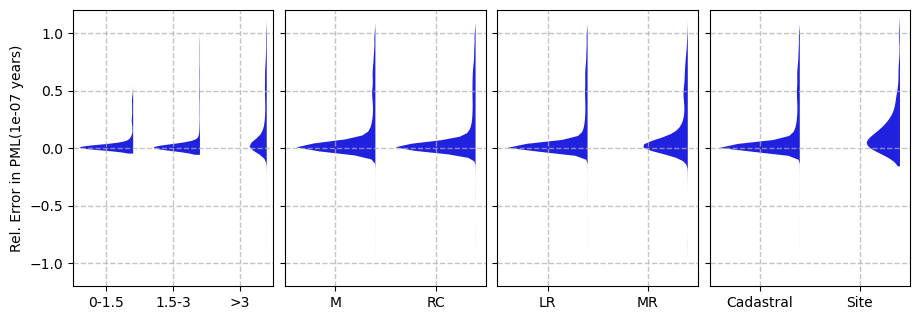

Index: 49 PoE: 1e-08


/tmp/ipykernel_3444078/2947217400.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(xticklabels_elevation)
/tmp/ipykernel_3444078/2947217400.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[3].set_xticklabels(xticklabels_level)


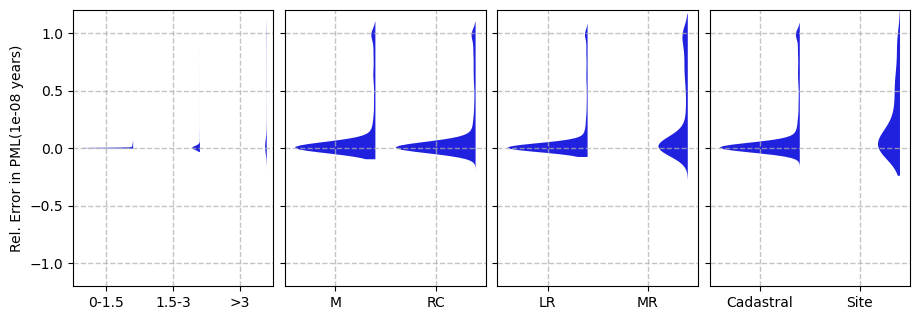

In [89]:
for point in t:
    RP = np.logspace(3, 8, 50, base=10)
    PoE = [1/rp for rp in RP]   
    # Find PoE index closest to the current point
    idx = (np.abs(np.array(PoE) - point)).argmin()
    print('Index:', idx, 'PoE:', PoE[idx])

    asset_perf_true = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_true.csv')[['agg_id', 'IDAG', 'value', f'PoE{idx}']]
    asset_perf_pred = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_asset_1658.csv')[['agg_id', 'IDAG', 'value', f'PoE{idx}']]
    asset_perf_true['PML_rel_err'] = (asset_perf_true[f'PoE{idx}'] - asset_perf_pred[f'PoE{idx}']) / asset_perf_true[f'PoE{idx}']
    del asset_perf_pred
    asset_perf_true = asset_perf_true[asset_perf_true[f'PoE{idx}'] > 1e-2]

    foglio_perf_true = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_foglio_true.csv')[['agg_id', 'foglio_id', 'value', f'PoE{idx}']]
    foglio_perf_pred = pd.read_csv(f'{MLDir}/risk/results/risk_calc/4_PML_table_foglio_1658.csv')[['agg_id', 'foglio_id', 'value', f'PoE{idx}']]
    foglio_perf_true['PML_rel_err'] = (foglio_perf_true[f'PoE{idx}'] - foglio_perf_pred[f'PoE{idx}']) / foglio_perf_true[f'PoE{idx}']
    del foglio_perf_pred
    foglio_perf_true = foglio_perf_true[foglio_perf_true[f'PoE{idx}'] > 1e-2]

    # Merge the two dataframes
    asset_perf_true2 = asset_perf_true.copy()
    asset_perf_true2['IDAG'] = 'site'
    asset_perf_true2.columns = ['agg_id', 'level', 'value', 'PoE', 'PML_rel_err']
    foglio_perf_true['foglio_id'] = 'foglio'
    foglio_perf_true.columns = ['agg_id', 'level', 'value', 'PoE', 'PML_rel_err']
    combined_perf_true = pd.concat([asset_perf_true2, foglio_perf_true], ignore_index=True)

    # Merge the two dataframes using the 'IDAG' column
    exposure = pd.read_csv(f'{MLDir}/risk/loss/building_exposure.csv')
    asset_perf_true = pd.merge(asset_perf_true, exposure, on='IDAG', how='inner')

    # Categories - Construction Type(M or RC), Floor Type(LR, MR, HR), Elevation(0-1.5, 1.5-3, 3)
    ele_edges = [0, 1.5, 3, 10]
    asset_perf_true['ele_bin'] = pd.cut(asset_perf_true['Elevation'], ele_edges)

    fig, axs = plt.subplots(1, 4, figsize=(9, 3), sharey=True)
    axs = axs.flatten()

    sns.violinplot(x='ele_bin', y='PML_rel_err', data=asset_perf_true, ax=axs[0], split=True, inner=None,
                   edgecolor=None,color='blue', linewidth=1)
    axs[0].set_xticklabels(xticklabels_elevation)

    sns.violinplot(x='Construction', y='PML_rel_err', data=asset_perf_true, ax=axs[1], split=True, inner=None,
                   edgecolor=None,color='blue', linewidth=1)

    sns.violinplot(x='FloorType', y='PML_rel_err', data=asset_perf_true, ax=axs[2], split=True, inner=None,
                   edgecolor=None,color='blue', linewidth=1)

    sns.violinplot(x='level', y='PML_rel_err', data=combined_perf_true, ax=axs[3], split=True, inner=None,
                   edgecolor=None,color='blue', linewidth=1)
    axs[3].set_xticklabels(xticklabels_level)

    # Titles for each subplot
    titles = ['Site Elevation', 'Construction Material', 'Structural Typology', 'Aggregation Level']
    xaxis_label = ['Elevation(m)', 'Material', 'Floor System', 'Units']

    # Set the titles for each subplot
    for i, ax in enumerate(axs):
        # if point == t[0]:
        #     ax.set_title(titles[i])
        # else:
        #     ax.set_title('')
        ax.set_xlabel(None)
        # if point == t[-1]:
        #     ax.set_xlabel(xaxis_label[i])
        ax.grid(axis='x', linestyle='--', alpha=0.75, linewidth=1)
        ax.grid(axis='y', linestyle='--', alpha=0.75, linewidth=1)
        ax.set_ylim(-1.2, 1.2)
    axs[0].set_ylabel(f'Rel. Error in PML({point:.0e} years)')

    # Adjust the layout to prevent overlap
    plt.tight_layout(pad=0, w_pad=0.5, h_pad=0.5)
    fig.suptitle(None)

    # Display the plot
    plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_sensitivity_PoE{point:.0e}_violin.png',bbox_inches='tight')
    plt.show()


Impact of uncertanity

AAL: 107.34073267325243 

AAL: 326.02145212936824 

AAL: 1440.767566413528 



AAL: 26487.531068567467 

AAL: 111534.93108773929 

AAL: 20169.989239660295 

AAL: 92.37297178560608 

AAL: 278.7210735522744 

AAL: 1299.4793165687759 

AAL: 24424.060314078404 

AAL: 102926.51040758169 

AAL: 18543.52825523648 

AAL: 20169.989239660295 



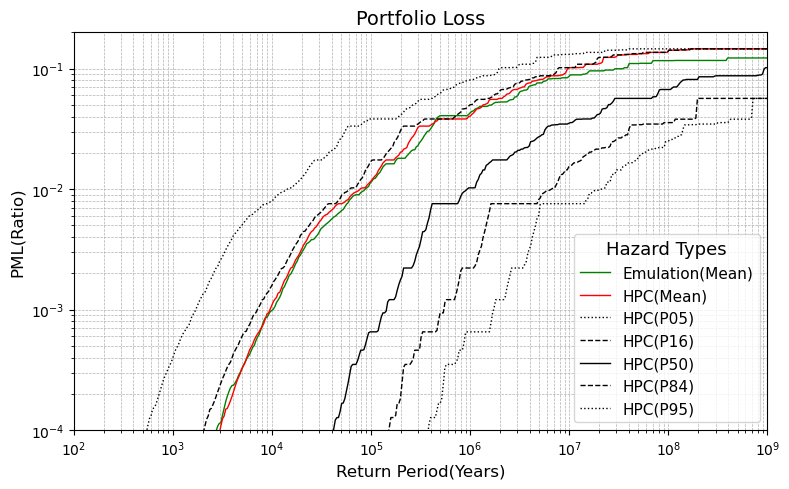

In [22]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = np.logspace(1, 9, num=500, base=10)
PoE = [1/rp for rp in RP]
min_loss = 500

#merge event_info with rates 
event_info = pd.read_csv(f'{MLDir}/risk/results/3_event_info_agg_loss.csv',header=0)
rates = pd.read_csv(f'{MLDir}/resources/processed/all_eventsBS_PS53550_perce_rates.txt')
#rename column from ID to eve_id
rates = rates.rename(columns={'ID':'eve_id'})
event_info = pd.merge(event_info,rates,on='eve_id',how='inner')

#True PML
PML_05 = get_loss_pml(event_info['loss_true'],event_info['P05'],min_loss,PoE)[1]
PML_16 = get_loss_pml(event_info['loss_true'],event_info['P16'],min_loss,PoE)[1]
PML_50 = get_loss_pml(event_info['loss_true'],event_info['P50'],min_loss,PoE)[1]
PML_84 = get_loss_pml(event_info['loss_true'],event_info['P84'],min_loss,PoE)[1]
PML_95 = get_loss_pml(event_info['loss_true'],event_info['P95'],min_loss,PoE)[1]
PML_mean = get_loss_pml(event_info['loss_true'],event_info['Pmean'],min_loss,PoE)[1]

#Emulation PML
PML_05_E = get_loss_pml(event_info['loss_1658'],event_info['P05'],min_loss,PoE)[1]
PML_16_E = get_loss_pml(event_info['loss_1658'],event_info['P16'],min_loss,PoE)[1]
PML_50_E = get_loss_pml(event_info['loss_1658'],event_info['P50'],min_loss,PoE)[1]
PML_84_E = get_loss_pml(event_info['loss_1658'],event_info['P84'],min_loss,PoE)[1]
PML_95_E = get_loss_pml(event_info['loss_1658'],event_info['P95'],min_loss,PoE)[1]
PML_mean_E = get_loss_pml(event_info['loss_1658'],event_info['Pmean'],min_loss,PoE)[1]

#compute relative error for each threshold of return period between predictions and true
rel_error_05 = (PML_05 - PML_05_E)/PML_05
rel_error_16 = (PML_16 - PML_16_E)/PML_16
rel_error_50 = (PML_50 - PML_50_E)/PML_50
rel_error_84 = (PML_84 - PML_84_E)/PML_84
rel_error_95 = (PML_95 - PML_95_E)/PML_95
rel_error_mean = (PML_mean - PML_mean_E)/PML_mean

#plot
fig, ax = plt.subplots(figsize=(8, 5))

# Use a professional color palette percentiles(0.05,0.16,0.5,0.84,0.95), mean
colors = ['k', 'g' ]
lines = ['-', ':','--']

#Emulation
ax.plot(RP, PML_mean_E, label='Emulation(Mean)', color='g', linewidth=1.0,linestyle=lines[0])
# ax.plot(RP, PML_84_E, label='Emulation(84%)', color=colors[1], linewidth=1.0,linestyle=lines[1])
# ax.plot(RP, PML_95_E, label='Emulation(95%)', color=colors[1], linewidth=1.0,linestyle=lines[2])
#True
ax.plot(RP, PML_mean, label='HPC(Mean)', color='r', linewidth=1.0,linestyle=lines[0])
ax.plot(RP, PML_05, label='HPC(P05)', color=colors[0], linewidth=1.0,linestyle=lines[1])
ax.plot(RP, PML_16, label='HPC(P16)', color=colors[0], linewidth=1.0,linestyle=lines[2])
ax.plot(RP, PML_50, label='HPC(P50)', color=colors[0], linewidth=1.0,linestyle=lines[0])
ax.plot(RP, PML_84, label='HPC(P84)', color=colors[0], linewidth=1.0,linestyle=lines[2])
ax.plot(RP, PML_95, label='HPC(P95)', color=colors[0], linewidth=1.0,linestyle=lines[1])



#get nevents exceeding threshold probability of 1e-4, 1e-6, 1e-8 depths
total_value = 28491684200
t = [1e-4,1e-5,1e-6,1e-7,1e-8]
ncount = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE,total_value,t)[-1]
# #get counts of events exceeding threshold probability of 1e-4, 1e-6, 1e-8
# ax.text(1.5*(1e3),0.14, '#'+str(event_info.shape[0]-ncount[0])+'/'+str(event_info.shape[0]), color='k')
# ax.text(1.5*(1e4),.14, '#'+str(ncount[0]-ncount[1])+'/'+str(event_info.shape[0]), color='k')
# ax.text(1.5*(1e5),.14, '#'+str(ncount[1]-ncount[2])+'/'+str(event_info.shape[0]), color='k')
# ax.text(1.5*(1e6),.14, '#'+str(ncount[2]-ncount[3])+'/'+str(event_info.shape[0]), color='k')
# ax.text(1.5*(1e7),.14, '#'+str(ncount[3])+'/'+str(event_info.shape[0]), color='k')

#draw vertical line exceed threshold probability of 1e4, 1e6, 1e8
# ax.axvline(x=1e4, color='grey', linestyle='--')
# ax.axvline(x=1e5, color='grey', linestyle='--')
# ax.axvline(x=1e6, color='grey', linestyle='--')
# ax.axvline(x=1e7, color='grey', linestyle='--')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Return Period(Years)', fontsize=12)
ax.set_ylabel('PML(Ratio)', fontsize=12)
ax.set_title('Portfolio Loss', fontsize=14)
ax.set_xlim(1e2, 1e9)
ax.set_ylim(1e-4, 2e-1)
# ax.set_yticks([0.0001, 0.0005,0.001, 0.005, 0.01, 0.02, 0.04,.06,.08,.1,]) 
# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend
ax.legend(title='Hazard Types', title_fontsize='13', fontsize='11',ncol=1)

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Show plot
plt.tight_layout()
plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_portfolio_uncertainity.png')
plt.show()

# #plot exceedance curve
# plt.figure(figsize=(5, 5))
# plt.plot(rel_error_mean,PoE, label='Emul. Error(mean)', color='k',linewidth=1,linestyle=lines[0])
# plt.plot(rel_error_84,PoE, label='Emul. Error(84%)', color='r',linewidth=1,linestyle=lines[1])
# plt.plot(rel_error_95,PoE, label='Emul. Error(95%)', color='b',linewidth=1,linestyle=lines[2])
# plt.axvline(0, color='black', linestyle='--', linewidth=1)
# plt.ylabel('Probability of Exceedance')
# plt.xlabel('Relative Error')
# plt.yscale('log')
# plt.grid(True)
# plt.xlim(-1, 1)
# plt.ylim(1e-8,1e-2)
# plt.legend(ncol=1)
# plt.title(f'Portfolio Loss')
# plt.savefig(f'{MLDir}/risk/plots/risk_compare/risk_rel_err_portfolio_uncertainity.png')
# plt.show()



Floortypes - LR,MR,HR

LR
AAL: 14055.26698772663 

AAL: 10463.766705322454 

AAL: 12825.75884479819 

AAL: 11296.26639942978 

AAL: 11681.00099794961 

MR
AAL: 6114.607423119903 

AAL: 4120.0898771568345 

AAL: 5717.599542723172 

AAL: 4633.034528412147 

AAL: 4765.184654642047 



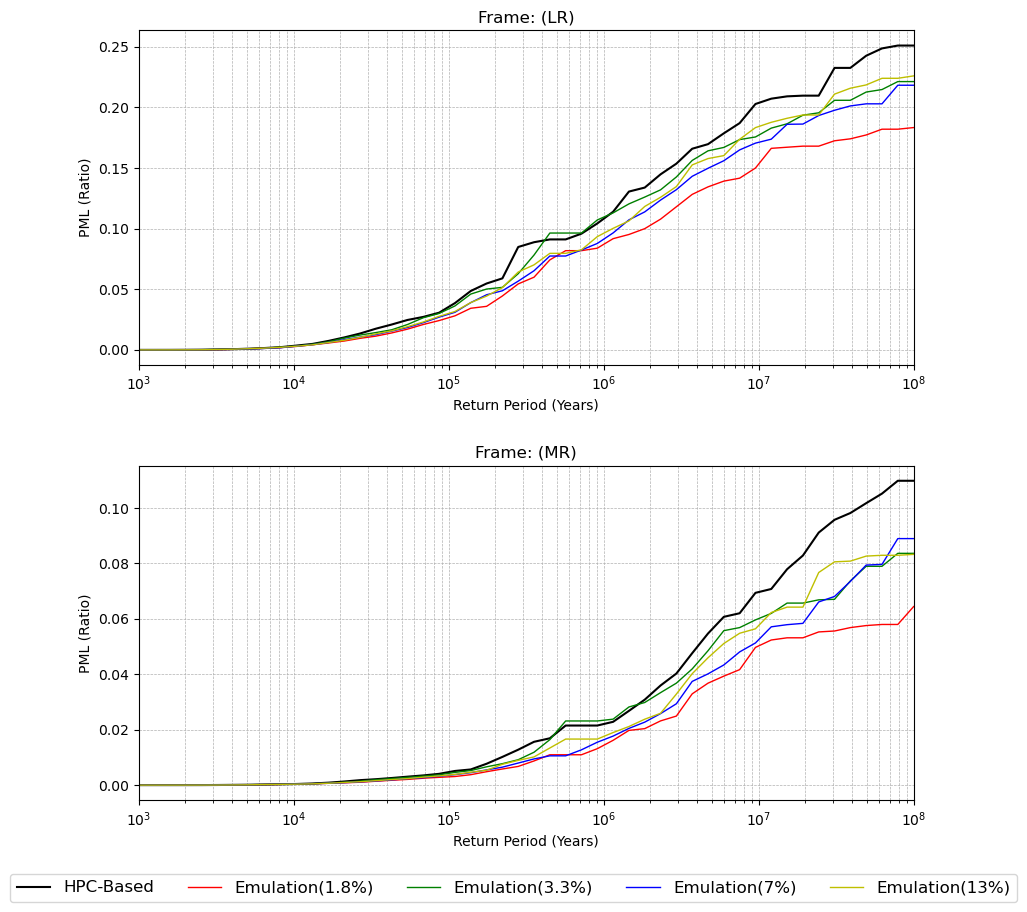

AAL: 14055.26698772663 

AAL: 10463.766705322454 

AAL: 12825.75884479819 

AAL: 11296.26639942978 

AAL: 11681.00099794961 

AAL: 6114.607423119903 

AAL: 4120.0898771568345 

AAL: 5717.599542723172 

AAL: 4633.034528412147 

AAL: 4765.184654642047 



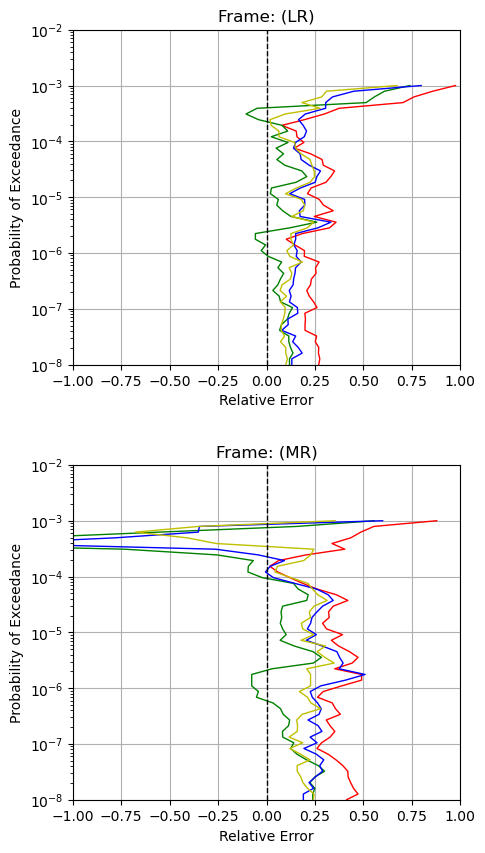

In [117]:
#read loss event table
event_info = pd.read_csv(f'{MLDir}/risk/results/3_event_info_Floor_loss.csv',header=0)

#get exposure values and classes
exposure_val = pd.read_csv(f'{MLDir}/risk/exposure/Admin_units/floor_values.csv')

ClassType = exposure_val['Floor'].unique()[:2]

# Initialize a figure with 12 subplots for the 12 sites
fig, axes = plt.subplots(2, 1, figsize=(10, 10))  # 3 rows, 4 columns
axes = axes.flatten()
fig.subplots_adjust(hspace=0.3, wspace=0.2)
RP = np.logspace(3,8,50,base=10)
PoE = [1/rp for rp in RP]   
t = [1e-4,1e-6,1e-8]
min_loss = 500

for idx, select_pt in enumerate(ClassType):  # 
    print(select_pt)
    total_value = int(exposure_val[exposure_val['Floor'] == select_pt]['Value'])
    pml_true = get_loss_pml(event_info[f'loss_{select_pt}_true'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_0 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[0]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_1 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[1]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_2 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[2]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_3 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[3]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    
    # Compute relative errors
    rel_error_0 = (pml_true - pml_0) / pml_true
    rel_error_1 = (pml_true - pml_1) / pml_true
    rel_error_2 = (pml_true - pml_2) / pml_true
    rel_error_3 = (pml_true - pml_3) / pml_true
      
    # Determine subplot position
    ax = axes[idx]
    # Plot PML exceedance curve
    ax.plot(RP, pml_true, label='HPC-Based', color='k', linewidth=1.5)
    ax.plot(RP, pml_0, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(RP, pml_1, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(RP, pml_2, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(RP, pml_3, label='Emulation(13%)', color='y', linewidth=1)
    
    # Plot settings
    ax.set_title(f'Frame: ({select_pt})')
    ax.set_xlabel('Return Period (Years)')
    ax.set_ylabel('PML (Ratio)')
    ax.set_xscale('log')
    ax.set_xlim(1e3, 1e8)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.0),  # Move legend closer to the subplots
)

# Save the figure
plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_frame.png')
plt.show()

# Initialize another figure for relative errors
fig, axes = plt.subplots(2, 1, figsize=(5, 10))
axes = axes.flatten()
fig.subplots_adjust(hspace=0.3, wspace=0.2)

for idx, select_pt in enumerate(ClassType):  # 
    total_value = int(exposure_val[exposure_val['Floor'] == select_pt]['Value'])
    pml_true = get_loss_pml(event_info[f'loss_{select_pt}_true'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_0 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[0]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_1 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[1]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_2 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[2]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_3 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[3]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    
    rel_error_0 = (pml_true - pml_0) / pml_true
    rel_error_1 = (pml_true - pml_1) / pml_true
    rel_error_2 = (pml_true - pml_2) / pml_true
    rel_error_3 = (pml_true - pml_3) / pml_true
    
    ax = axes[idx]
    
    # Plot relative error curves
    ax.plot(rel_error_0, PoE, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(rel_error_1, PoE, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(rel_error_2, PoE, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(rel_error_3, PoE, label='Emulation(13%)', color='y', linewidth=1)
    
    # Plot settings
    ax.set_title(f'Frame: ({select_pt})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Probability of Exceedance')
    ax.set_xlabel('Relative Error')
    ax.set_yscale('log')
    ax.set_xlim(-1, 1)
    ax.set_ylim(1e-8, 1e-2)
    ax.grid(True)

# Save the figure
plt.savefig(f'{MLDir}/risk/plots/risk_compare/risk_rel_error_frame.png')
plt.show()


AAL: 5483.0493565797005 

AAL: 4224.474314430875 

AAL: 5064.435776483128 

AAL: 4501.820260216358 

AAL: 4629.8264158496295 

AAL: 3775.2237414369442 

AAL: 2357.1753942543196 

AAL: 3291.292384035587 

AAL: 2665.1350256451283 

AAL: 2822.894433631805 

AAL: 8572.161907577618 

AAL: 6239.275575377265 

AAL: 7761.305170143953 

AAL: 6794.419032509815 

AAL: 7051.139703456049 

AAL: 2339.3201117759977 

AAL: 1762.8774245089028 

AAL: 2426.2833290224858 

AAL: 1967.8591631460163 

AAL: 1942.253045172613 

AAL: 0.0018950774633524254 

AAL: 1.913038413179889e-05 

AAL: 0.0 

AAL: 5.778655494597933e-06 

AAL: 1.2350293642532152e-05 



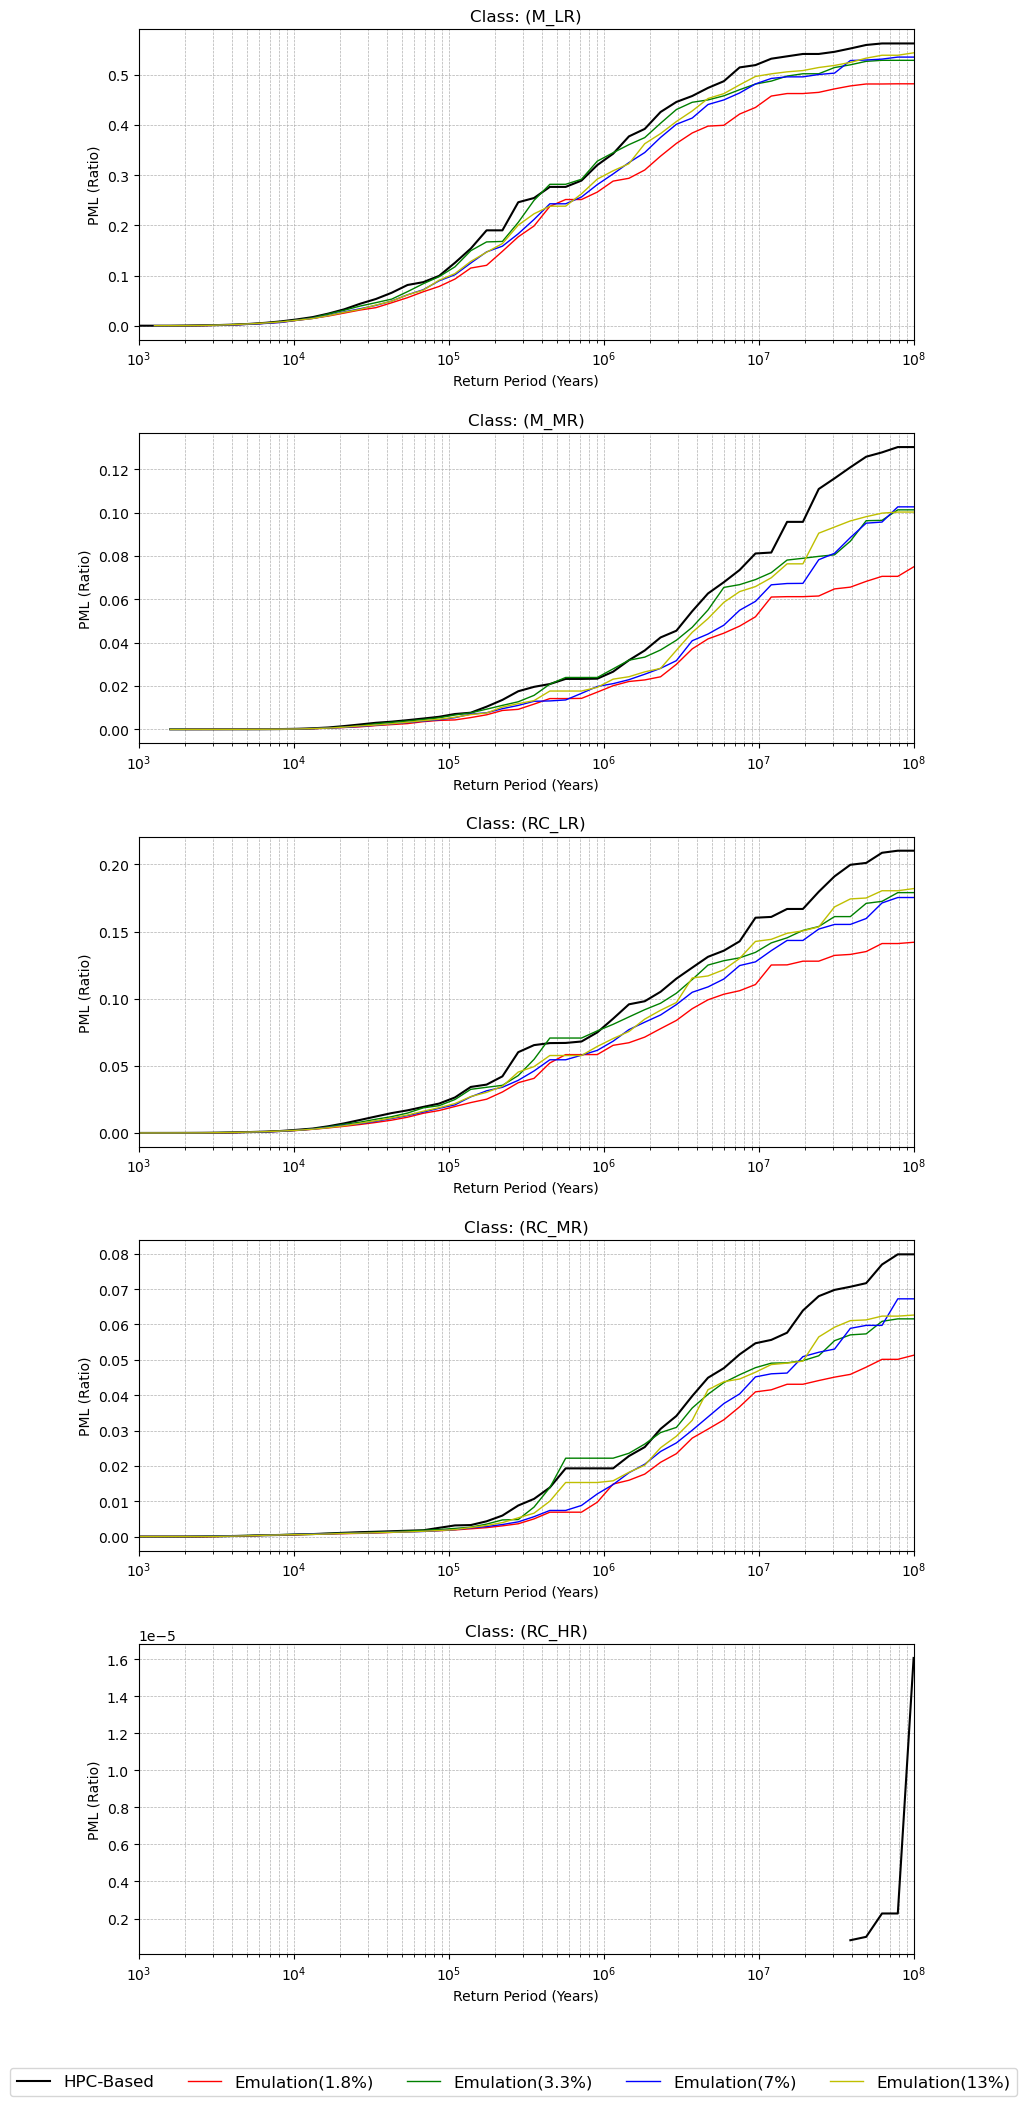

AAL: 5483.0493565797005 

AAL: 4224.474314430875 

AAL: 5064.435776483128 

AAL: 4501.820260216358 

AAL: 4629.8264158496295 

AAL: 3775.2237414369442 

AAL: 2357.1753942543196 

AAL: 3291.292384035587 

AAL: 2665.1350256451283 

AAL: 2822.894433631805 

AAL: 8572.161907577618 

AAL: 6239.275575377265 

AAL: 7761.305170143953 

AAL: 6794.419032509815 

AAL: 7051.139703456049 

AAL: 2339.3201117759977 

AAL: 1762.8774245089028 

AAL: 2426.2833290224858 

AAL: 1967.8591631460163 

AAL: 1942.253045172613 

AAL: 0.0018950774633524254 

AAL: 1.913038413179889e-05 

AAL: 0.0 

AAL: 5.778655494597933e-06 

AAL: 1.2350293642532152e-05 



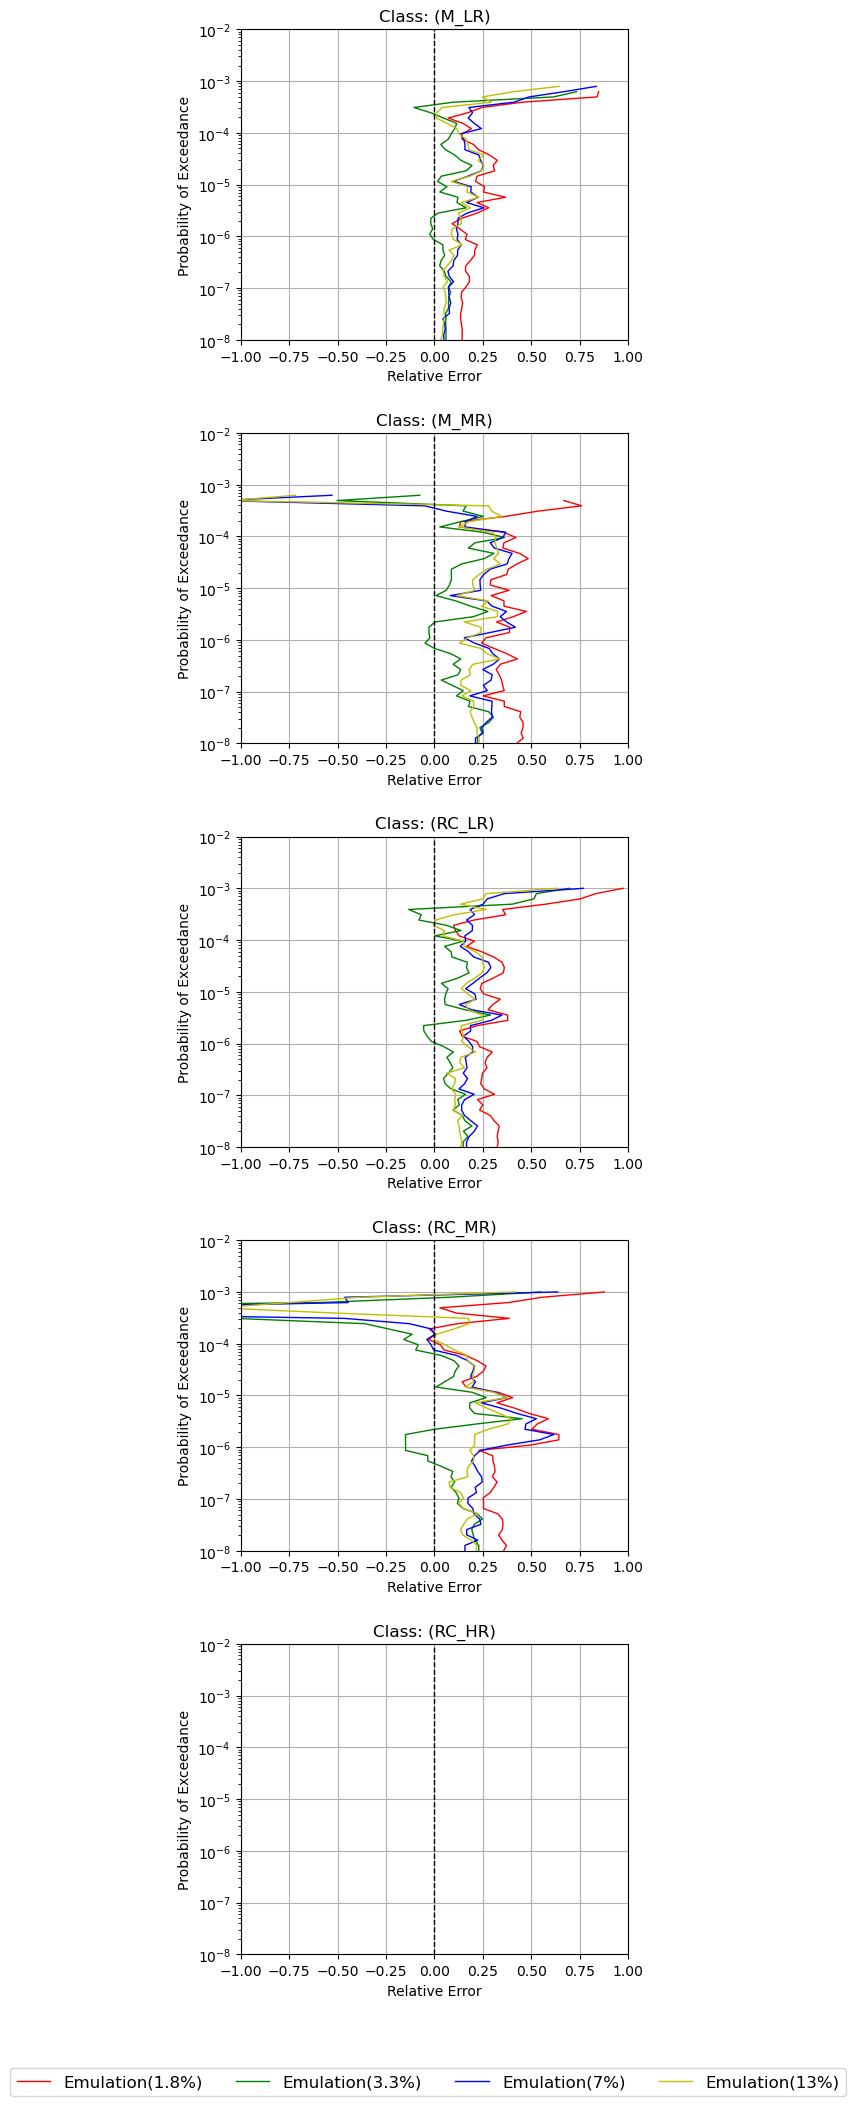

In [130]:
#read loss event table
event_info = pd.read_csv(f'{MLDir}/risk/results/3_event_info_Class_loss.csv',header=0)

#get exposure values and classes
exposure_val = pd.read_csv(f'{MLDir}/risk/exposure/Admin_units/class_values.csv')

ClassType = exposure_val['Class'].unique()

# Initialize a figure with 12 subplots for the 12 sites
fig, axes = plt.subplots(5, 1, figsize=(10, 25))  
axes = axes.flatten()
fig.subplots_adjust(hspace=0.3, wspace=0.2)
RP = np.logspace(3,8,50,base=10)
PoE = [1/rp for rp in RP]   
t = [1e-4,1e-6,1e-8]
min_loss = 500

for idx, select_pt in enumerate(ClassType):  # 
    total_value = int(exposure_val[exposure_val['Class'] == select_pt]['Value'])
    pml_true = get_loss_pml(event_info[f'loss_{select_pt}_true'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_0 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[0]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_1 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[1]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_2 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[2]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_3 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[3]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    
    # Compute relative errors
    rel_error_0 = (pml_true - pml_0) / pml_true
    rel_error_1 = (pml_true - pml_1) / pml_true
    rel_error_2 = (pml_true - pml_2) / pml_true
    rel_error_3 = (pml_true - pml_3) / pml_true
      
    # Determine subplot position
    ax = axes[idx]
    # Plot PML exceedance curve
    ax.plot(RP, pml_true, label='HPC-Based', color='k', linewidth=1.5)
    ax.plot(RP, pml_0, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(RP, pml_1, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(RP, pml_2, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(RP, pml_3, label='Emulation(13%)', color='y', linewidth=1)
    
    # Plot settings
    ax.set_title(f'Class: ({select_pt})')
    ax.set_xlabel('Return Period (Years)')
    ax.set_ylabel('PML (Ratio)')
    ax.set_xscale('log')
    ax.set_xlim(1e3, 1e8)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.05),  # Move legend closer to the subplots
)

# Save the figure
plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_class.png',bbox_inches='tight')
plt.show()

# Initialize another figure for relative errors
fig, axes = plt.subplots(5, 1, figsize=(5, 25))
axes = axes.flatten()
fig.subplots_adjust(hspace=0.3, wspace=0.2)

for idx, select_pt in enumerate(ClassType):  # 
    total_value = int(exposure_val[exposure_val['Class'] == select_pt]['Value'])
    pml_true = get_loss_pml(event_info[f'loss_{select_pt}_true'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_0 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[0]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_1 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[1]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_2 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[2]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    pml_3 = get_loss_pml(event_info[f'loss_{select_pt}_{list_size[3]}'],event_info['mean_prob'],min_loss,PoE,total_value)[1]
    
    rel_error_0 = (pml_true - pml_0) / pml_true
    rel_error_1 = (pml_true - pml_1) / pml_true
    rel_error_2 = (pml_true - pml_2) / pml_true
    rel_error_3 = (pml_true - pml_3) / pml_true
    
    ax = axes[idx]
    
    # Plot relative error curves
    ax.plot(rel_error_0, PoE, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(rel_error_1, PoE, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(rel_error_2, PoE, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(rel_error_3, PoE, label='Emulation(13%)', color='y', linewidth=1)
    
    # Plot settings
    ax.set_title(f'Class: ({select_pt})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Probability of Exceedance')
    ax.set_xlabel('Relative Error')
    ax.set_yscale('log')
    ax.set_xlim(-1, 1)
    ax.set_ylim(1e-8, 1e-2)
    ax.grid(True)

# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.05),  # Move legend closer to the subplots
)

# Save the figure
plt.savefig(f'{MLDir}/risk/plots/risk_compare/risk_rel_error_class.png',bbox_inches='tight')
plt.show()
